# Tool Performance Analysis: IMG/VR4 Real Data (v3)

Analysis of alignment search tool performance on real CRISPR spacer data from iPHoP against
IMG/VR4 HQ viral contigs across multiple dataset fractions.

## Analysis overview

Multi-metric validation (parasail) is used to assign Hamming distance, edit distance, and
gap-affine distance to each unique alignment region, enabling fair cross-tool comparison.
Recall is computed as the fraction of validated unique alignment regions (grouped by
`region_idx` with `COORDINATE_TOLERANCE` bp tolerance) detected by each tool.

## Output conventions

- Main figures: `draft/main/figures/performance/` (minimap2 excluded)
- Supplementary figures: `draft/supp/figures/performance/` (includes `_w_minimap2` variants)
- Tables: `draft/main/figures/tables/` and `draft/supp/figures/tables/` as TSV (+ parquet where large)
- Multi-panel figures include explicit panel labels (`A.`, `B.`, etc.)
- The suffix-less filename is used in the main text; `_w_minimap2` suffix marks reviewer copies

## Distance metrics

- Hamming distance (substitutions only): primary analysis, all fractions
- Edit distance (allows indels): secondary analysis, smaller fractions only (where sassy ran)


In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

os.chdir('/clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/')

import json
import glob
import subprocess
import logging
from pathlib import Path
from typing import Optional, Union, Any

import polars as pl
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import upsetplot as up

from lets_plot import *
from bench.utils.functions import *

LetsPlot.setup_html()
pl.Config.set_tbl_cols(n=-1)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

logger = logging.getLogger(__name__)

# -- Analysis parameters --
MAX_HAMMING_DISTANCE = 3
MAX_EDIT_DISTANCE = 3
COORDINATE_TOLERANCE = 5
GAP_OPEN_PENALTY = 5 # not used, for ref only
GAP_EXTEND_PENALTY = 5 # not used, for ref only

# -- Paths --
RESULTS_BASE_DIR = Path('results/real_data/subsamples')
OUTPUT_DIR = Path('results/real_data')
SPACERS_FILE = 'imgvr4_data/spacers/iphop_filtered_spacers.fna'
HIGH_INS_SIM_DIR = Path('results/simulated/ns_500_nc_5000_HIGH_INSERTION_RATE')

MAIN_FIG_DIR = Path('draft/main/figures/performance')
SUPP_FIG_DIR = Path('draft/supp/figures/performance')
MAIN_TABLE_DIR = Path('draft/main/figures/tables')
SUPP_TABLE_DIR = Path('draft/supp/figures/tables')
RESULTS_PLOT_DIR = OUTPUT_DIR / 'plots_fraction_1'

for _d in [MAIN_FIG_DIR, SUPP_FIG_DIR, MAIN_TABLE_DIR, SUPP_TABLE_DIR, RESULTS_PLOT_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# -- Tool styles from JSON --
with open('notebooks/tool_styles.json', 'r') as f:
    TOOL_STYLES = json.load(f)

tool_colors = {t: s['color'] for t, s in TOOL_STYLES.items()}
tool_shapes = {t: s['letsplot_shape_num'] for t, s in TOOL_STYLES.items()}
tool_markers_mpl = {t: s.get('matplotlib_marker', 'o') for t, s in TOOL_STYLES.items()}


# -- Save helpers --
def save_mpl_figure_bundle(fig: plt.Figure, stem: str, output_dirs, dpi: int = 300, write_png: bool = True) -> None:
    """Save matplotlib figure as SVG (and optionally PNG) to each directory in output_dirs."""
    for out_dir in output_dirs:
        out_dir = Path(out_dir)
        fig.savefig(out_dir / f"{stem}.svg", bbox_inches='tight')
        if write_png:
            fig.savefig(out_dir / f"{stem}.png", dpi=dpi, bbox_inches='tight')


def save_lets_plot_bundle(plot_obj, stem: str, output_dirs, w: int = 1200, h: int = 800, dpi: int = 300) -> None:
    """Save a lets-plot object as SVG and PNG to each directory in output_dirs."""
    for out_dir in output_dirs:
        out_dir = Path(out_dir)
        plot_obj.to_svg(str(out_dir / f"{stem}.svg"))
        plot_obj.to_png(str(out_dir / f"{stem}.png"), w=w, h=h, dpi=dpi, unit='px')


def export_table(df: pl.DataFrame, stem: str, output_dirs) -> None:
    """Write a polars DataFrame as TSV to each directory in output_dirs."""
    for out_dir in output_dirs:
        out_dir = Path(out_dir)
        df.write_csv(out_dir / f"{stem}.tsv", separator='\t')


# -- minimap2 handling --
# Suffix convention: suffix-less = main text (minimap2 excluded)
#                   _w_minimap2 = supplementary/reviewer copy (minimap2 included)

def filter_tools(df, include_minimap2: bool):
    """Remove minimap2 unless include_minimap2 is True. Accepts a pl.DataFrame or a list of tool names."""
    if not include_minimap2:
        if isinstance(df, list):
            return [t for t in df if t != 'minimap2']
        return df.filter(pl.col('tool') != 'minimap2')
    return df


def figure_stem(base: str, include_minimap2: bool) -> str:
    """Return filename stem with _w_minimap2 suffix when minimap2 is included."""
    return base if not include_minimap2 else f"{base}_w_minimap2"

print(f"MAX_HAMMING_DISTANCE={MAX_HAMMING_DISTANCE}, MAX_EDIT_DISTANCE={MAX_EDIT_DISTANCE}")

print(f"Loaded tool styles for {len(TOOL_STYLES)} tools: {sorted(TOOL_STYLES)}")

MAX_HAMMING_DISTANCE=3, MAX_EDIT_DISTANCE=3
Loaded tool styles for 11 tools: ['blastn', 'bowtie1', 'bowtie2', 'indelfree_bruteforce', 'indelfree_indexed', 'minimap2', 'mmseqs2', 'mummer4', 'sassy', 'strobealign', 'x_mapper']


## Step 1: Discover Fractions and Collect Metadata

Auto-discover all fraction directories, check which tools completed or timed out, and collect
dataset size statistics (number of contigs, total bp). Spacer statistics (constant across all
fractions) are also collected from the iPHoP filtered spacer set.


In [2]:
def get_fraction_metadata(fraction_dir: Path) -> dict:
    """
    Collect metadata for one fraction directory.

    Checks raw_outputs for completed tool files and scans SLURM .err logs for TIMEOUT/CANCELLED
    markers. Returns a dict with fraction name, dataset size, completed tools, and timed-out tools.
    """
    fraction_name = fraction_dir.name
    fraction_value = float(fraction_name.replace('fraction_', ''))
    metadata = {'fraction': fraction_name, 'fraction_value': fraction_value}

    # Dataset size from contig file
    contig_file = fraction_dir / 'subsampled_data' / 'subsampled_contigs.fa'
    if contig_file.exists():
        cstats = get_seq_stats_pl(str(contig_file))
        metadata['n_contigs'] = cstats['n_seqs'].item() if 'n_seqs' in cstats.columns else 0
        metadata['total_bp'] = cstats['total_bp'].item() if 'total_bp' in cstats.columns else 0
    else:
        metadata['n_contigs'] = 0
        metadata['total_bp'] = 0

    # Tool completion check via raw output file existence
    raw_outputs_dir = fraction_dir / 'raw_outputs'
    expected_outputs = {
        'blastn': 'blastn_output.tsv',
        'bowtie1': 'bowtie1_output.sam',
        'bowtie2': 'bowtie2_output.sam',
        'indelfree_bruteforce': 'indelfree_bruteforce_output.sam',
        'indelfree_indexed': 'indelfree_indexed_output.sam',
        'minimap2': 'minimap2_output.sam',
        'mmseqs2': 'mmseqs_output.tsv',
        'mummer4': 'mummer4_output.sam',
        'sassy': 'sassy.tsv',
        'strobealign': 'strobealign_output.sam',
        'x_mapper': 'x_mapper_output.sam',
    }
    completed_tools = []
    missing_tools = []
    for tool, fname in expected_outputs.items():
        p = raw_outputs_dir / fname
        if p.exists() and p.stat().st_size > 0:
            completed_tools.append(tool)
        else:
            missing_tools.append(tool)

    # Timeout detection from SLURM .err logs
    timed_out_tools = []
    slurm_logs_dir = fraction_dir / 'slurm_logs'
    if slurm_logs_dir.exists():
        for tool in expected_outputs:
            for log_file in slurm_logs_dir.glob(f'{tool}*.err'):
                try:
                    content = log_file.read_text(errors='replace')
                    if any(kw in content for kw in ('TIMEOUT', 'CANCELLED', 'DUE TO TIME LIMIT')):
                        timed_out_tools.append(tool)
                        if tool in completed_tools:
                            completed_tools.remove(tool)
                        break
                except OSError:
                    pass

    metadata['completed_tools'] = sorted(completed_tools)
    metadata['timed_out_tools'] = sorted(set(timed_out_tools))
    metadata['missing_tools'] = sorted(set(missing_tools) - set(timed_out_tools))
    metadata['n_tools_completed'] = len(completed_tools)
    return metadata


# Discover and describe all fractions
all_fractions = sorted(
    [d for d in RESULTS_BASE_DIR.iterdir() if d.is_dir() and d.name.startswith('fraction_')],
    key=lambda x: float(x.name.replace('fraction_', ''))
)

fractions_metadata = [get_fraction_metadata(d) for d in all_fractions]
fractions_df = pl.DataFrame(fractions_metadata)

print(f"Discovered {len(all_fractions)} fractions")
print(fractions_df.select(['fraction', 'n_contigs', 'total_bp', 'n_tools_completed']))

for row in fractions_df.iter_rows(named=True):
    print(f"\n{row['fraction']}  ({row['n_tools_completed']} tools completed)")
    if row['completed_tools']:
        print(f"  Completed : {', '.join(row['completed_tools'])}")
    if row['timed_out_tools']:
        print(f"  Timed out : {', '.join(row['timed_out_tools'])}")
    if row['missing_tools']:
        print(f"  Missing   : {', '.join(row['missing_tools'])}")


Discovered 7 fractions
shape: (7, 4)
┌─────────────────┬───────────┬──────────┬───────────────────┐
│ fraction        ┆ n_contigs ┆ total_bp ┆ n_tools_completed │
│ ---             ┆ ---       ┆ ---      ┆ ---               │
│ str             ┆ i64       ┆ i64      ┆ i64               │
╞═════════════════╪═══════════╪══════════╪═══════════════════╡
│ fraction_0.0005 ┆ 279       ┆ 0        ┆ 11                │
│ fraction_0.001  ┆ 421       ┆ 0        ┆ 11                │
│ fraction_0.005  ┆ 2107      ┆ 0        ┆ 10                │
│ fraction_0.01   ┆ 4214      ┆ 0        ┆ 10                │
│ fraction_0.05   ┆ 21071     ┆ 0        ┆ 9                 │
│ fraction_0.1    ┆ 42143     ┆ 0        ┆ 9                 │
│ fraction_1      ┆ 421431    ┆ 0        ┆ 8                 │
└─────────────────┴───────────┴──────────┴───────────────────┘

fraction_0.0005  (11 tools completed)
  Completed : blastn, bowtie1, bowtie2, indelfree_bruteforce, indelfree_indexed, minimap2, mmseqs2, mumme

In [16]:
# Compute and export sequence statistics
seq_stat_rows = []

# Spacer set (constant across all fractions)
spacer_stats = get_seq_stats_pl(SPACERS_FILE).with_columns(
    pl.lit('spacers').alias('type'),
    pl.lit('all_spacers').alias('name')
)
seq_stat_rows.append(spacer_stats)

# Per-fraction contig stats
for fraction_dir in all_fractions:
    contig_file = fraction_dir / 'subsampled_data' / 'subsampled_contigs.fa'
    if not contig_file.exists():
        print(f"Missing contig file for {fraction_dir.name}, skipping")
        continue
    cstats = get_seq_stats_pl(str(contig_file)).with_columns(
        pl.lit('contigs').alias('type'),
        pl.lit(fraction_dir.name).alias('name')
    )
    seq_stat_rows.append(cstats)

if seq_stat_rows:
    seq_stats_df = pl.concat(seq_stat_rows, how='vertical_relaxed').with_columns(
        pl.col('file').cast(pl.Utf8)
    )
    seq_stats_df.write_csv(OUTPUT_DIR / 'all_sequence_stats.csv')
    seq_stats_df.write_csv(SUPP_TABLE_DIR / 'real_dataset_sequence_stats.tsv', separator='\t')
    print(seq_stats_df)
    print(f"Saved sequence stats to {SUPP_TABLE_DIR / 'real_dataset_sequence_stats.tsv'}")


shape: (8, 10)
┌────────────────────────────────────────────────────────────────────────────────────┬─────────┬───────────────┬──────────────┬────────────┬────────────┬────────────┬──────────────┬─────────┬─────────────────┐
│ file                                                                               ┆ n_seqs  ┆ median_length ┆ avg_length   ┆ sum_length ┆ min_length ┆ max_length ┆ gc_frac_mean ┆ type    ┆ name            │
│ ---                                                                                ┆ ---     ┆ ---           ┆ ---          ┆ ---        ┆ ---        ┆ ---        ┆ ---          ┆ ---     ┆ ---             │
│ str                                                                                ┆ i32     ┆ f64           ┆ f64          ┆ i32        ┆ i32        ┆ i32        ┆ f64          ┆ str     ┆ str             │
╞════════════════════════════════════════════════════════════════════════════════════╪═════════╪═══════════════╪══════════════╪════════════╪═════

In [3]:
seq_stats_df = pl.read_csv(OUTPUT_DIR / 'all_sequence_stats.csv')

## Step 2: Load Multi-Metric Validation Files

Each fraction directory contains a `multi_metric_distances.parquet` with parasail-validated
distances (Hamming, edit, gap-affine) for every unique alignment region. These were generated
by `compare-results --multi-metric`. Load each file, filter out `all_tools_combined` and
timed-out tools, then cache as a dict keyed by fraction name.


In [4]:
# Cache of loaded DataFrames: fraction_name -> pl.DataFrame (long format, tools exploded)
fraction_cache: dict[str, pl.DataFrame] = {}

for row in fractions_df.iter_rows(named=True):
    fraction_name = row['fraction']
    parquet_file = RESULTS_BASE_DIR / fraction_name / 'multi_metric_distances.parquet'

    if not parquet_file.exists():
        print(f"Missing multi_metric_distances.parquet for {fraction_name} - skipping")
        continue

    timed_out: set[str] = set(row['timed_out_tools']) if row['timed_out_tools'] else set()

    df = (
        pl.read_parquet(parquet_file)
        .explode('tools')
        .rename({'tools': 'tool'})
        .filter(pl.col('tool') != 'all_tools_combined')
    )
    if timed_out:
        df = df.filter(~pl.col('tool').is_in(sorted(timed_out)))

    fraction_cache[fraction_name] = df
    tools_found = sorted(df['tool'].unique().to_list())
    print(f"{fraction_name}: {df.height:,} rows, {len(tools_found)} tools: {tools_found}")

print(f"\nLoaded {len(fraction_cache)} fractions into cache")


fraction_0.0005: 393,423 rows, 11 tools: ['blastn', 'bowtie1', 'bowtie2', 'indelfree_bruteforce', 'indelfree_indexed', 'minimap2', 'mmseqs2', 'mummer4', 'sassy', 'strobealign', 'x_mapper']
fraction_0.001: 581,883 rows, 11 tools: ['blastn', 'bowtie1', 'bowtie2', 'indelfree_bruteforce', 'indelfree_indexed', 'minimap2', 'mmseqs2', 'mummer4', 'sassy', 'strobealign', 'x_mapper']
fraction_0.005: 2,577,620 rows, 10 tools: ['blastn', 'bowtie1', 'bowtie2', 'indelfree_indexed', 'minimap2', 'mmseqs2', 'mummer4', 'sassy', 'strobealign', 'x_mapper']
fraction_0.01: 5,710,052 rows, 10 tools: ['blastn', 'bowtie1', 'bowtie2', 'indelfree_indexed', 'minimap2', 'mmseqs2', 'mummer4', 'sassy', 'strobealign', 'x_mapper']
fraction_0.05: 5,990,328 rows, 9 tools: ['blastn', 'bowtie1', 'bowtie2', 'indelfree_indexed', 'minimap2', 'mmseqs2', 'mummer4', 'strobealign', 'x_mapper']
fraction_0.1: 12,555,624 rows, 9 tools: ['blastn', 'bowtie1', 'bowtie2', 'indelfree_indexed', 'minimap2', 'mmseqs2', 'mummer4', 'strobeal

## Step 3: Cross-Fraction Recall Analysis

Compute recall per tool per fraction at Hamming distance <=3 (using `region_idx` grouping to avoid double-counting alignments that shift slightly across coordinate boundaries). The resulting table is exported as a pivot TSV (tools × fractions). A summary figure shows mean recall +-SD across all fractions, highlighting tools with the most consistent performance.

**Unit**: recall is unitless (0 to 1), in this context it's from unique alignment regions, so fraction of validated unique alignment regions detected by each tool relative to all tools combined.


In [5]:
# Compute recall per tool per fraction (Hamming <=3)
all_fractions_rows = []

for row in fractions_df.iter_rows(named=True):
    fraction_name = row['fraction']
    df = fraction_cache.get(fraction_name)
    if df is None:
        continue

    frac_hamming = df.filter(pl.col('distance_hamming') <= MAX_HAMMING_DISTANCE)
    total_regions = frac_hamming.select(['spacer_id', 'contig_id', 'region_idx']).unique().height
    if total_regions == 0:
        continue

    for tool in sorted(frac_hamming['tool'].unique().to_list()):
        tool_regions = (
            frac_hamming.filter(pl.col('tool') == tool)
            .select(['spacer_id', 'contig_id', 'region_idx']).unique().height
        )
        all_fractions_rows.append({
            'fraction': fraction_name,
            'fraction_value': row['fraction_value'],
            'tool': tool,
            'recall': tool_regions / total_regions,
            'n_regions': tool_regions,
            'total_possible': total_regions,
        })

all_fractions_df = pl.DataFrame(all_fractions_rows)
print(f"Cross-fraction recall DataFrame: {all_fractions_df.height} rows")
print(f"Fractions: {sorted(all_fractions_df['fraction'].unique().to_list())}")
print(f"Tools: {sorted(all_fractions_df['tool'].unique().to_list())}")

# Export recall pivot table: tools x fractions
recall_pivot = (
    all_fractions_df
    .select(['tool', 'fraction', 'recall'])
    .pivot(index='tool', on='fraction', values='recall')
    .sort('tool')
)
export_table(recall_pivot, 'imgvr4_recall_by_fraction_pivot_hamming_le3', [SUPP_TABLE_DIR])
recall_pivot.write_csv(str(OUTPUT_DIR / 'recall_by_fraction_pivot_hamming_le3.tsv'), separator='\t')
print(recall_pivot)


Cross-fraction recall DataFrame: 68 rows
Fractions: ['fraction_0.0005', 'fraction_0.001', 'fraction_0.005', 'fraction_0.01', 'fraction_0.05', 'fraction_0.1', 'fraction_1']
Tools: ['blastn', 'bowtie1', 'bowtie2', 'indelfree_bruteforce', 'indelfree_indexed', 'minimap2', 'mmseqs2', 'mummer4', 'sassy', 'strobealign', 'x_mapper']
shape: (11, 8)
┌──────────────────────┬─────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬──────────────┬────────────┐
│ tool                 ┆ fraction_0.0005 ┆ fraction_0.001 ┆ fraction_0.005 ┆ fraction_0.01 ┆ fraction_0.05 ┆ fraction_0.1 ┆ fraction_1 │
│ ---                  ┆ ---             ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---          ┆ ---        │
│ str                  ┆ f64             ┆ f64            ┆ f64            ┆ f64           ┆ f64           ┆ f64          ┆ f64        │
╞══════════════════════╪═════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪══

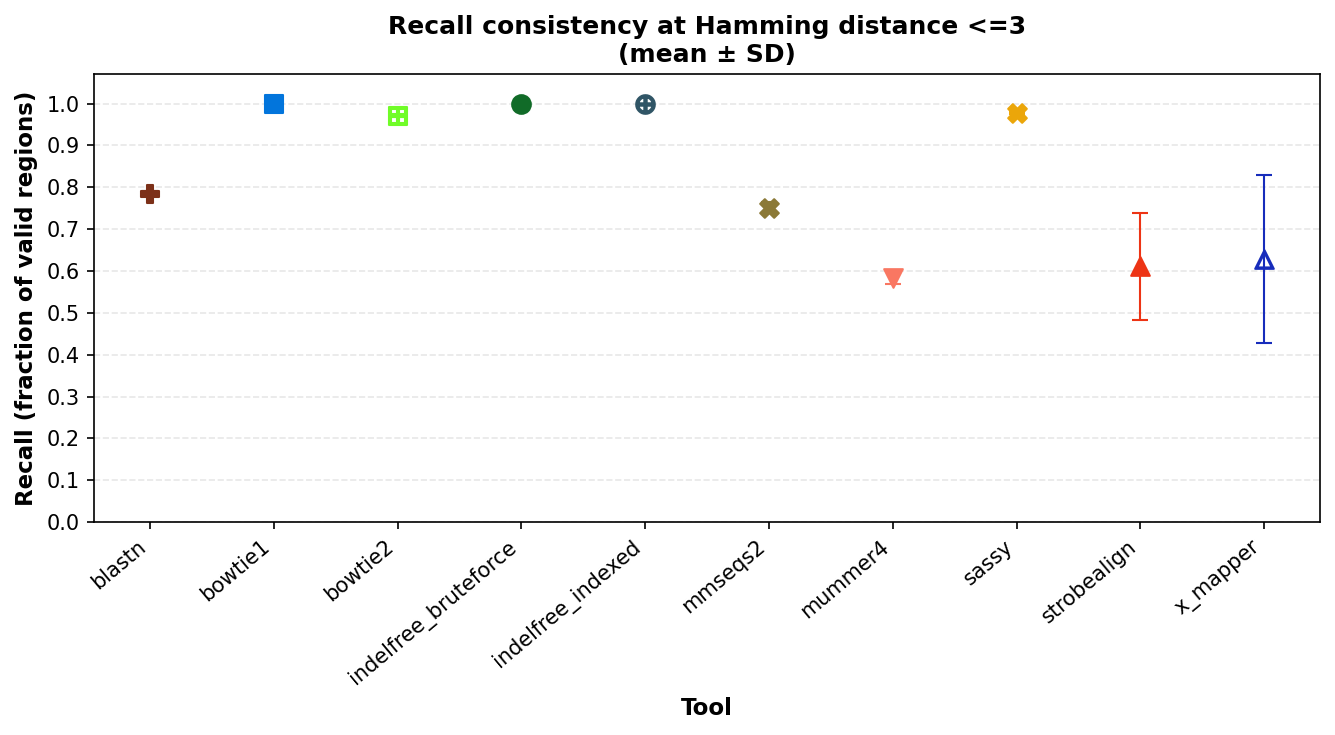

Saved imgvr4_across_fractions_recall_consistency_hamming_le3


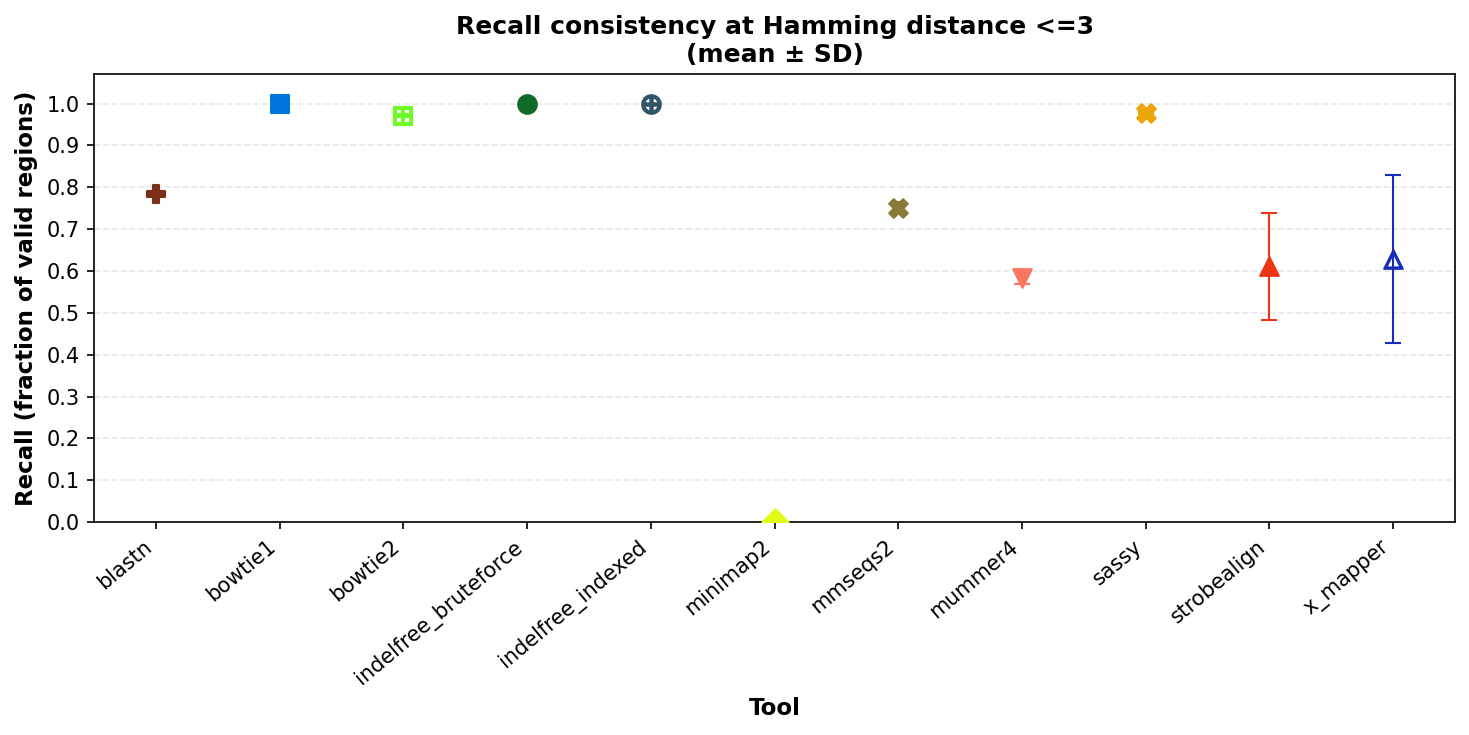

Saved imgvr4_across_fractions_recall_consistency_hamming_le3_w_minimap2
shape: (11, 6)
┌──────────────────────┬─────────────┬────────────┬────────────┬────────────┬─────────────┐
│ tool                 ┆ mean_recall ┆ std_recall ┆ min_recall ┆ max_recall ┆ n_fractions │
│ ---                  ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ ---         │
│ str                  ┆ f64         ┆ f64        ┆ f64        ┆ f64        ┆ i64         │
╞══════════════════════╪═════════════╪════════════╪════════════╪════════════╪═════════════╡
│ indelfree_bruteforce ┆ 1.0         ┆ 0.0        ┆ 1.0        ┆ 1.0        ┆ 2           │
│ indelfree_indexed    ┆ 0.999977    ┆ 0.000022   ┆ 0.999949   ┆ 1.0        ┆ 6           │
│ bowtie1              ┆ 0.999927    ┆ 0.000034   ┆ 0.999904   ┆ 1.0        ┆ 7           │
│ sassy                ┆ 0.976923    ┆ 0.0026     ┆ 0.973927   ┆ 0.979859   ┆ 4           │
│ bowtie2              ┆ 0.971314    ┆ 0.003576   ┆ 0.966235   ┆ 0.977659   ┆ 7      

In [6]:
# Mean recall +/- SD across fractions per tool, plotted with matplotlib
# Main version excludes minimap2; supplementary variant includes it.

def plot_crossfraction_consistency(df: pl.DataFrame, include_minimap2: bool) -> plt.Figure:
    """
    Error-bar plot of mean recall +/- SD across fractions per tool.

    Args:
        df: all_fractions_df with columns tool, recall, fraction
        include_minimap2: whether minimap2 is included
    Returns:
        matplotlib Figure
    """
    plot_df = filter_tools(df, include_minimap2)
    tools_sorted = sorted(plot_df['tool'].unique().to_list())

    means, stds, mins_r, maxs_r = [], [], [], []
    for t in tools_sorted:
        td = plot_df.filter(pl.col('tool') == t)['recall']
        means.append(td.mean())
        stds.append(td.std() if td.len() > 1 else 0.0)
        mins_r.append(td.min())
        maxs_r.append(td.max())

    fig, ax = plt.subplots(figsize=(max(8, len(tools_sorted) * 0.9), 5), dpi=150)
    x = np.arange(len(tools_sorted))
    colors = [tool_colors.get(t, '#555555') for t in tools_sorted]
    markers = [tool_markers_mpl.get(t, 'o') for t in tools_sorted]

    for i, (t, m, s, mn, mx) in enumerate(zip(tools_sorted, means, stds, mins_r, maxs_r)):
        ax.errorbar(i, m, yerr=s, fmt='none', color=colors[i], capsize=4, linewidth=1)
        ax.scatter(i, m, color=colors[i], marker=markers[i], s=80, zorder=4,linewidths=1)

    ax.set_xticks(x)
    ax.set_xticklabels(tools_sorted, rotation=40, ha='right', fontsize=10)
    ax.set_ylim(0, 1.07)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
    ax.set_ylabel('Recall (fraction of valid regions)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tool', fontsize=11, fontweight='bold')
    ax.set_title(
        'Recall consistency at Hamming distance <=3\n'
        '(mean ± SD)',
        fontsize=12, fontweight='bold'
    )
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    fig.tight_layout()
    return fig


for include_mm2 in [False, True]:
    fig = plot_crossfraction_consistency(all_fractions_df, include_minimap2=include_mm2)
    stem = figure_stem('imgvr4_across_fractions_recall_consistency_hamming_le3', include_mm2)
    target_dirs = [SUPP_FIG_DIR, OUTPUT_DIR] if include_mm2 else [MAIN_FIG_DIR, SUPP_FIG_DIR, OUTPUT_DIR]
    save_mpl_figure_bundle(fig, stem, target_dirs, dpi=320)
    plt.show()
    plt.close(fig)
    print(f"Saved {stem}")

# Export summary stats table
tool_stats_rows = []
for t in sorted(all_fractions_df['tool'].unique().to_list()):
    td = all_fractions_df.filter(pl.col('tool') == t)['recall']
    tool_stats_rows.append({
        'tool': t,
        'mean_recall': td.mean(),
        'std_recall': (td.std() if td.len() > 1 else 0.0),
        'min_recall': td.min(),
        'max_recall': td.max(),
        'n_fractions': td.len(),
    })
tool_stats_df = pl.DataFrame(tool_stats_rows).sort('mean_recall', descending=True)
export_table(tool_stats_df, 'imgvr4_across_fractions_recall_stats_hamming_le3', [MAIN_TABLE_DIR, SUPP_TABLE_DIR])
print(tool_stats_df)


## Step 4: Fraction_1 Detailed Analysis

Load the full dataset (fraction_1) for per-tool comparison at Hamming distance <=3.
Tools that timed out are excluded (partial results would bias comparisons).

Summary statistics and upset plots are exported to the supplementary directory.

In [7]:
# -- Load fraction_1 --
results_hamming3 = fraction_cache['fraction_1'].filter(
    pl.col('distance_hamming') <= MAX_HAMMING_DISTANCE
)
tools_in_results = sorted(results_hamming3['tool'].unique().to_list())

print(f"fraction_1 at Hamming <={MAX_HAMMING_DISTANCE}")
print(f"Rows (long format): {results_hamming3.height:,}")
print(f"Unique regions: {results_hamming3.select(['spacer_id','contig_id','region_idx']).unique().height:,}")
print(f"Tools: {tools_in_results}")

# Per-tool summary statistics
summary_stats = results_hamming3.group_by('tool').agg([
    pl.len().alias('n_alignments'),
    pl.col('spacer_id').n_unique().alias('n_spacers'),
    pl.col('contig_id').n_unique().alias('n_contigs'),
    pl.col('distance_hamming').mean().alias('mean_hamming'),
    pl.col('distance_hamming').median().alias('median_hamming'),
]).sort('n_alignments', descending=True)

export_table(summary_stats, 'imgvr4_fraction1_tool_summary_hamming_le3', [SUPP_TABLE_DIR])
print(summary_stats)


fraction_1 at Hamming <=3
Rows (long format): 110,077,646
Unique regions: 23,277,167
Tools: ['blastn', 'bowtie1', 'bowtie2', 'minimap2', 'mmseqs2', 'mummer4', 'strobealign', 'x_mapper']
shape: (8, 6)
┌─────────────┬──────────────┬───────────┬───────────┬──────────────┬────────────────┐
│ tool        ┆ n_alignments ┆ n_spacers ┆ n_contigs ┆ mean_hamming ┆ median_hamming │
│ ---         ┆ ---          ┆ ---       ┆ ---       ┆ ---          ┆ ---            │
│ str         ┆ u64          ┆ u64       ┆ u64       ┆ f64          ┆ f64            │
╞═════════════╪══════════════╪═══════════╪═══════════╪══════════════╪════════════════╡
│ bowtie1     ┆ 23445897     ┆ 750231    ┆ 323178    ┆ 1.376975     ┆ 1.0            │
│ bowtie2     ┆ 22769157     ┆ 730413    ┆ 284333    ┆ 1.32926      ┆ 1.0            │
│ blastn      ┆ 18407819     ┆ 649595    ┆ 273656    ┆ 1.131333     ┆ 1.0            │
│ mmseqs2     ┆ 17109912     ┆ 633226    ┆ 222783    ┆ 1.000275     ┆ 1.0            │
│ mummer4     ┆ 1

## Step 5: Recall by Hamming Distance (fraction_1)

Panel A shows recall at each exact Hamming distance (0, 1, 2, 3).
Panel B shows cumulative recall (≤ d).

- Main text figure: no minimap2.
- Supplementary figure: includes minimap2 (`_w_minimap2` suffix).


In [8]:
def compute_recall_by_distance(
    df: pl.DataFrame,
    tools_list: list[str],
    distance_col: str = 'distance_hamming',
    distance_values: list[int] | None = None,
    mode: str = 'exact',  # 'exact' or 'cumulative'
) -> pl.DataFrame:
    """Compute per-tool recall at each distance value.

    mode='exact'     : regions whose minimum distance == d
    mode='cumulative': regions whose minimum distance <= d

    Each unique region (spacer_id, contig_id, region_idx) is assigned its
    MINIMUM distance across all tools.  This is the oracle "true" distance for
    that region — the best alignment any tool achieved.  Using the minimum SHOULD
    avoid double-counting regions across distance bins (a region with min_dist=1
    that some tools also report at distance 2 is counted only in the d=1 bin).

    A tool is credited with finding a region if it has any row for that region
    in df, regardless of the distance it individually reported.  This gives
    appropriate credit to tools that locate the correct region but with a
    suboptimal alignment score.
    """
    if distance_values is None:
        distance_values = list(range(MAX_HAMMING_DISTANCE + 1))

    # Minimum distance per unique region across all tools
    region_min = (
        df.group_by(['spacer_id', 'contig_id', 'region_idx'])
        .agg(pl.col(distance_col).min().alias('min_dist'))
    )

    # All (region, tool) pairs present in df — used to check whether a tool found a region
    region_tool_presence = (
        df.select(['spacer_id', 'contig_id', 'region_idx', 'tool'])
        .unique()
    )

    records = []
    for d in distance_values:
        # Select regions whose oracle distance falls in this bin
        if mode == 'exact':
            regions_at_d = region_min.filter(pl.col('min_dist') == d)
        else:
            regions_at_d = region_min.filter(pl.col('min_dist') <= d)

        total_at_d = regions_at_d.height

        # Intersect presence table with the bin's region set
        found_in_bin = region_tool_presence.join(
            regions_at_d.select(['spacer_id', 'contig_id', 'region_idx']),
            on=['spacer_id', 'contig_id', 'region_idx'],
            how='inner',
        )

        for tool in tools_list:
            n_found = found_in_bin.filter(pl.col('tool') == tool).height
            records.append({
                'tool': tool,
                'distance': d,
                'n_found': n_found,
                'n_total': total_at_d,
                'recall': n_found / total_at_d if total_at_d > 0 else 0.0,
            })

    return pl.DataFrame(records)


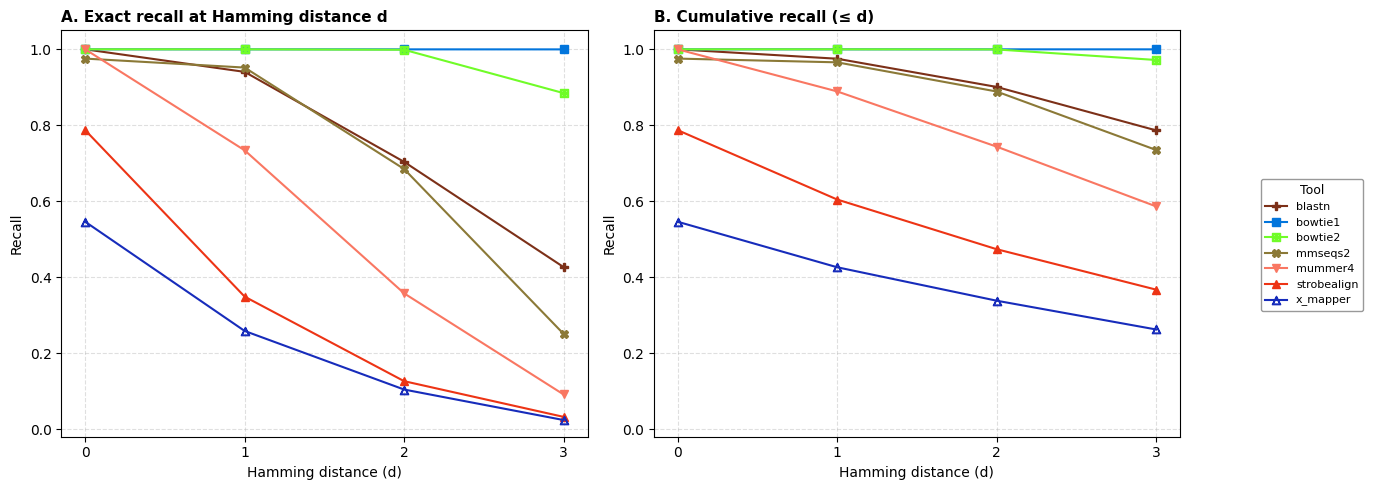

Saved imgvr4_fraction1_hamming_recall


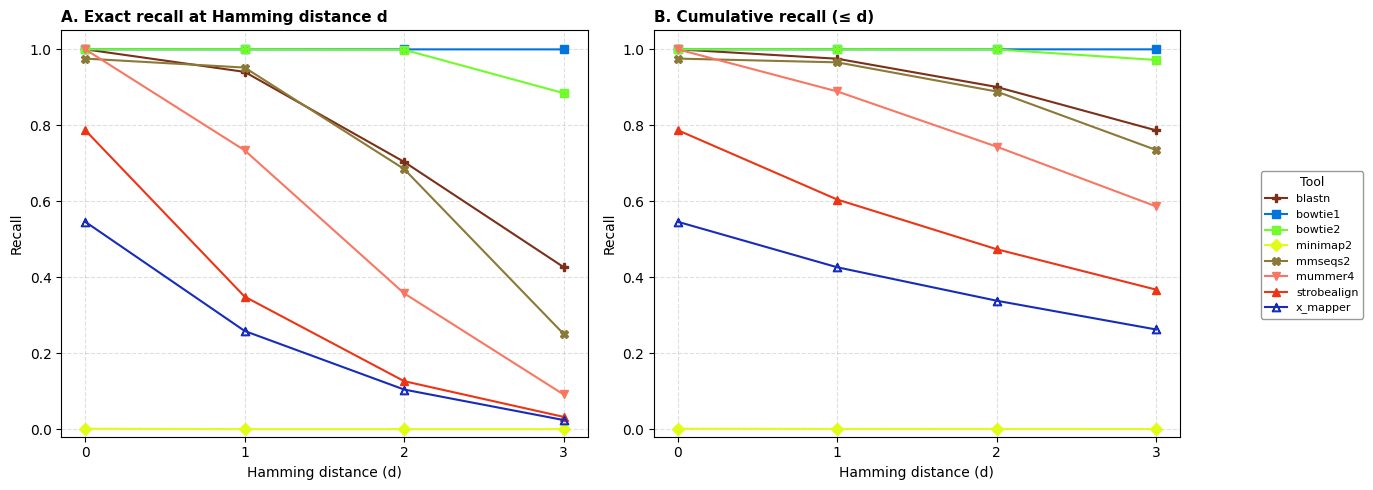

Saved imgvr4_fraction1_hamming_recall_w_minimap2


In [10]:
dist_values = list(range(MAX_HAMMING_DISTANCE + 1))

def _plot_hamming_recall_panels(
    results_df: pl.DataFrame,
    tools_list: list[str],
    include_minimap2: bool,
) -> plt.Figure:
    """Two-panel: A = exact recall, B = cumulative recall."""
    tlist = filter_tools(tools_list, include_minimap2=include_minimap2)
    legend_handles = []

    exact_df = compute_recall_by_distance(results_df, tlist, 'distance_hamming', dist_values, mode='exact')
    cumul_df = compute_recall_by_distance(results_df, tlist, 'distance_hamming', dist_values, mode='cumulative')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    for ax, df_plot, panel_label, title in [
        (axes[0], exact_df, 'A.', 'Exact recall at Hamming distance d'),
        (axes[1], cumul_df, 'B.', 'Cumulative recall (≤ d)'),
    ]:
        ax.set_title(f'{panel_label} {title}', loc='left', fontsize=11, fontweight='bold')
        for tool in tlist:
            tool_data = df_plot.filter(pl.col('tool') == tool).sort('distance')
            color = tool_colors.get(tool, '#888888')
            marker = tool_markers_mpl.get(tool, 'o')
            ax.plot(
                tool_data['distance'].to_list(),
                tool_data['recall'].to_list(),
                color=color, marker=marker, label=tool, linewidth=1.5, markersize=6,
            )

        ax.set_xlabel('Hamming distance (d)')
        ax.set_ylabel('Recall')
        ax.set_xticks(dist_values)
        ax.set_ylim(-0.02, 1.05)
        # ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, linestyle='--', alpha=0.4)

    handles = tlist

    fig.legend(
        handles,# labels,
        loc='center left',
        bbox_to_anchor=(1.05, 0.5),
        frameon=True,
        edgecolor='gray',
        title='Tool',
        fontsize=8,
        title_fontsize=9,
    )

    fig.tight_layout()
    return fig


for include_mm2 in [False, True]:
    stem = figure_stem('imgvr4_fraction1_hamming_recall', include_mm2)
    fig = _plot_hamming_recall_panels(results_hamming3, tools_in_results, include_minimap2=include_mm2)
    if include_mm2:
        save_mpl_figure_bundle(fig, stem, [SUPP_FIG_DIR])
    else:
        save_mpl_figure_bundle(fig, stem, [MAIN_FIG_DIR, SUPP_FIG_DIR])
    plt.show()
    plt.close(fig)
    print(f"Saved {stem}")

# Export recall tables
for mode in ['exact', 'cumulative']:
    recall_df = compute_recall_by_distance(results_hamming3, tools_in_results, 'distance_hamming', dist_values, mode=mode)
    export_table(recall_df, f'imgvr4_fraction1_hamming_recall_{mode}', [SUPP_TABLE_DIR])


## Step 6: Edit Distance Recall (Smaller Fractions with Sassy)

For fractions where sassy could be run (typically the smallest subsamples), we compute recall
using `distance_edit` instead of `distance_hamming`. This section produces a two-panel figure
analogous to Step 5.
#TODO: remove one of the legends (duplicated) and move it outside of the panels.

Fractions with sassy: ['fraction_0.0005', 'fraction_0.001', 'fraction_0.005', 'fraction_0.01']
Computed edit recall for fraction_0.0005
Computed edit recall for fraction_0.001
Computed edit recall for fraction_0.005
Computed edit recall for fraction_0.01


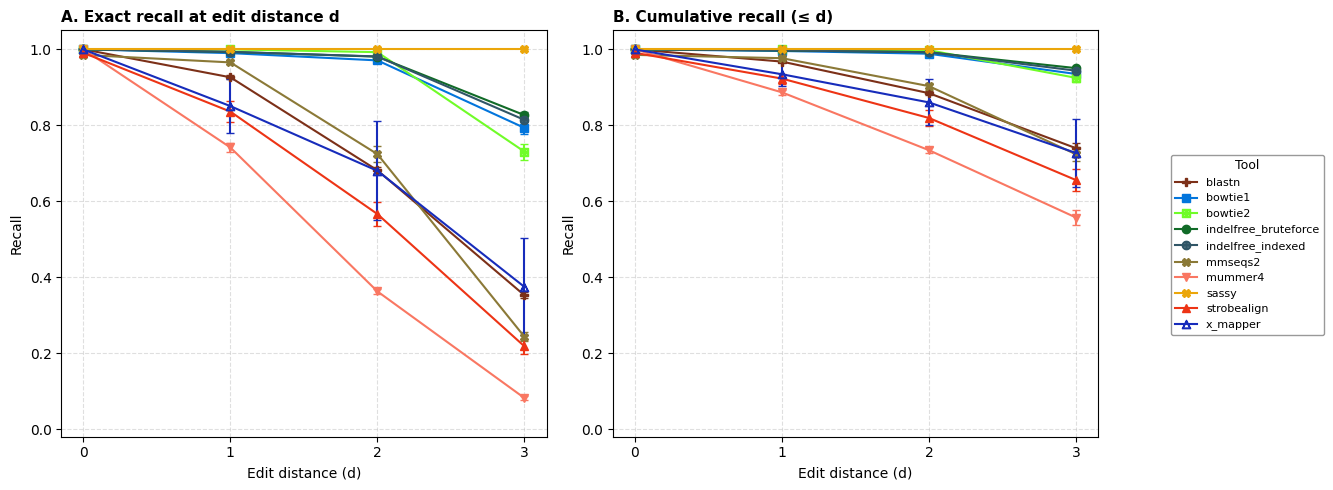

Saved imgvr4_sassy_fractions_edit_recall


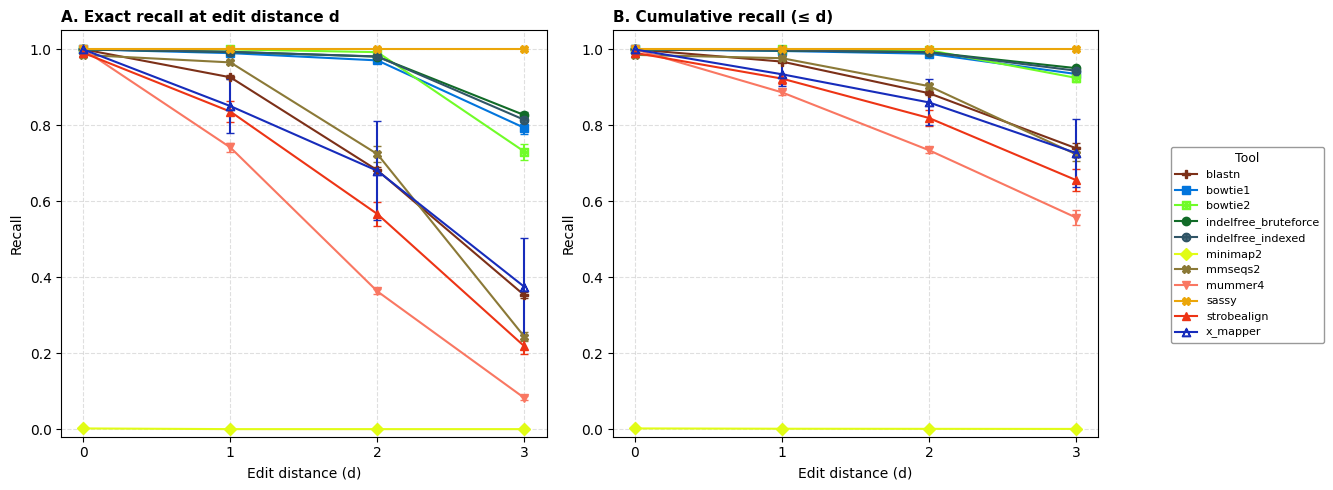

Saved imgvr4_sassy_fractions_edit_recall_w_minimap2


In [12]:
# -- Fractions where sassy completed --
sassy_fractions = (
    fractions_df
    .filter(pl.col('completed_tools').list.contains('sassy'))
    .sort('fraction_value')
)
print("Fractions with sassy:", sassy_fractions['fraction'].to_list())

def _plot_edit_recall_panels(
    recall_dfs: dict[str, pl.DataFrame],
    tools_list: list[str],
    include_minimap2: bool,
    mode: str,
) -> plt.Figure:
    """Single panel with mean ± SD across sassy-eligible fractions."""
    tlist = filter_tools(tools_list, include_minimap2=include_minimap2)
    all_rows = pl.concat(list(recall_dfs.values()))
    agg = (
        all_rows
        .filter(pl.col('tool').is_in(tlist))
        .group_by(['tool', 'distance'])
        .agg([
            pl.col('recall').mean().alias('mean_recall'),
            pl.col('recall').std().alias('std_recall'),
        ])
        .sort(['tool', 'distance'])
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    title_mode = 'Exact' if mode == 'exact' else 'Cumulative'
    ax.set_title(
        f'Edit distance recall ({title_mode}) – sassy-eligible fractions (mean ± SD)',
        fontsize=10,
    )
    for tool in tlist:
        td = agg.filter(pl.col('tool') == tool).sort('distance')
        color = tool_colors.get(tool, '#888888')
        marker = tool_markers_mpl.get(tool, 'o')
        xs = td['distance'].to_list()
        ys = td['mean_recall'].to_list()
        errs = [v if v is not None else 0.0 for v in td['std_recall'].to_list()]
        ax.errorbar(xs, ys, yerr=errs, color=color, marker=marker,
                    label=tool, linewidth=1.5, markersize=6, capsize=3)
    ax.set_xlabel('Edit distance (d)')
    ax.set_ylabel('Recall')
    ax.set_xticks(dist_values)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    return fig


# Collect per-fraction edit recall dicts
edit_recall_exact: dict[str, pl.DataFrame] = {}
edit_recall_cumul: dict[str, pl.DataFrame] = {}

for row in sassy_fractions.iter_rows(named=True):
    fname = row['fraction']
    df_frac = fraction_cache[fname]
    df_le3 = df_frac.filter(pl.col('distance_edit') <= MAX_HAMMING_DISTANCE)
    tools_frac = sorted(df_le3['tool'].unique().to_list())
    edit_recall_exact[fname] = compute_recall_by_distance(
        df_le3, tools_frac, 'distance_edit', dist_values, mode='exact'
    )
    edit_recall_cumul[fname] = compute_recall_by_distance(
        df_le3, tools_frac, 'distance_edit', dist_values, mode='cumulative'
    )
    print(f"Computed edit recall for {fname}")

# Combined tools across sassy fractions
all_edit_tools = sorted(set(
    t for df in edit_recall_exact.values() for t in df['tool'].unique().to_list()
))

# Two-panel figure: A = exact, B = cumulative
for include_mm2 in [False, True]:
    stem = figure_stem('imgvr4_sassy_fractions_edit_recall', include_mm2)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    tlist = filter_tools(all_edit_tools, include_minimap2=include_mm2)
    legend_handles: dict[str, Any] = {}

    for ax, mode_name, rec_dfs, plabel, ptitle in [
        (axes[0], 'exact', edit_recall_exact, 'A.', 'Exact recall at edit distance d'),
        (axes[1], 'cumulative', edit_recall_cumul, 'B.', 'Cumulative recall (≤ d)'),
    ]:
        all_rows = pl.concat(list(rec_dfs.values()))
        agg = (
            all_rows.filter(pl.col('tool').is_in(tlist))
            .group_by(['tool', 'distance'])
            .agg([
                pl.col('recall').mean().alias('mean_recall'),
                pl.col('recall').std().alias('std_recall')
            ])
            .sort(['tool', 'distance'])
        )
        ax.set_title(f'{plabel} {ptitle}', loc='left', fontsize=11, fontweight='bold')

        for tool in tlist:
            td = agg.filter(pl.col('tool') == tool).sort('distance')
            color = tool_colors.get(tool, '#888888')
            marker = tool_markers_mpl.get(tool, 'o')
            xs = td['distance'].to_list()
            ys = td['mean_recall'].to_list()
            errs = [v if v is not None else 0.0 for v in td['std_recall'].to_list()]
            eb = ax.errorbar(
                xs, ys, yerr=errs, color=color, marker=marker,
                label=tool, linewidth=1.5, markersize=6, capsize=3
            )
            if tool not in legend_handles:
                legend_handles[tool] = eb.lines[0]

        ax.set_xlabel('Edit distance (d)')
        ax.set_ylabel('Recall')
        ax.set_xticks(dist_values)
        ax.set_ylim(-0.02, 1.05)
        ax.grid(True, linestyle='--', alpha=0.4)

    # Single legend outside panels (right side)
    handles = [legend_handles[t] for t in tlist if t in legend_handles]
    labels = [t for t in tlist if t in legend_handles]
    fig.legend(
        handles, labels,
        loc='center left',
        bbox_to_anchor=(0.9, 0.5),

        frameon=True,
        edgecolor='gray',
        title='Tool',
        fontsize=8,
        title_fontsize=9,
    )

    # Leave room for external legend
    fig.tight_layout(rect=[0, 0, 0.86, 1])
    save_mpl_figure_bundle(fig, stem, [SUPP_FIG_DIR])
    plt.show()
    plt.close(fig)
    print(f"Saved {stem}")

# Export
for mode_name, rec_dfs in [('exact', edit_recall_exact), ('cumulative', edit_recall_cumul)]:
    combined = pl.concat([df.with_columns(pl.lit(fname).alias('fraction'))
                          for fname, df in rec_dfs.items()])
    export_table(combined, f'imgvr4_sassy_fractions_edit_recall_{mode_name}', [SUPP_TABLE_DIR])


## Step 7: Hamming vs Edit Distance Recall Heatmaps (Side-by-Side)

Panel A = Hamming recall at each distance, averaged across all fractions.
Panel B = Edit recall averaged across sassy-eligible fractions.
Rows = tools (colored by tool_colors), columns = distance 0..3. Grey cells indicate no data for that tool/distance combination.

Computed Hamming recall for fraction_0.0005
Computed Hamming recall for fraction_0.001
Computed Hamming recall for fraction_0.005
Computed Hamming recall for fraction_0.01
Computed Hamming recall for fraction_0.05
Computed Hamming recall for fraction_0.1
Computed Hamming recall for fraction_1


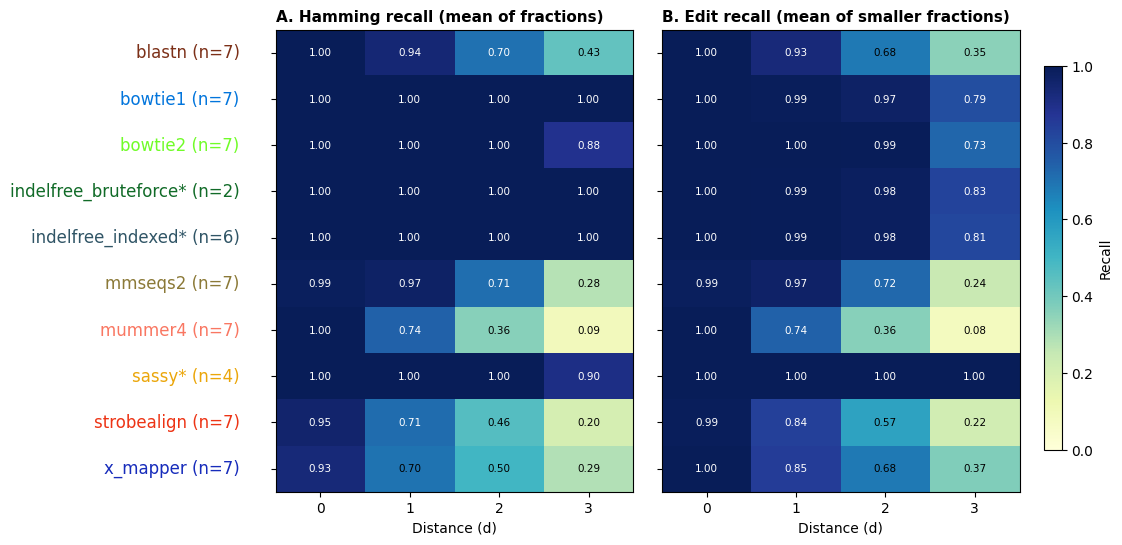

Saved imgvr4_heatmap_hamming_vs_edit


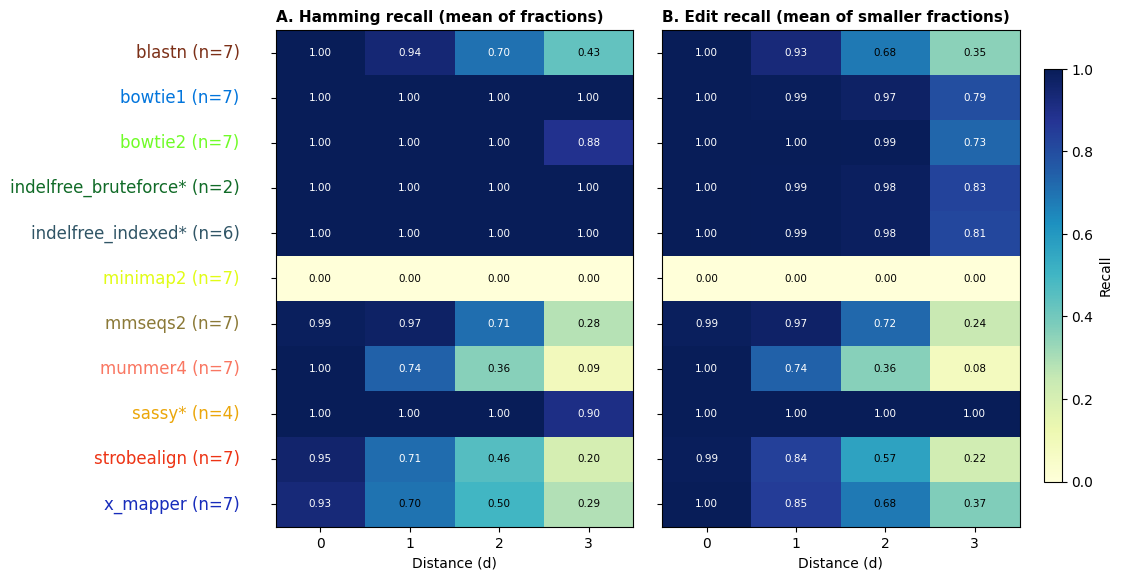

Saved imgvr4_heatmap_hamming_vs_edit_w_minimap2


In [16]:
import matplotlib.colors as mcolors
import numpy as np

def _build_recall_matrix(recall_df: pl.DataFrame, tools_list: list[str], dist_values: list[int]) -> np.ndarray:
    """Return a (n_tools x n_dist) array of recall values; NaN where tool not present."""
    mat = np.full((len(tools_list), len(dist_values)), np.nan)
    for i, tool in enumerate(tools_list):
        td = recall_df.filter(pl.col('tool') == tool)
        for j, d in enumerate(dist_values):
            row = td.filter(pl.col('distance') == d)
            if row.height > 0:
                mat[i, j] = row['recall'][0]
    return mat


def plot_heatmap_pair(
    hamming_exact_df: pl.DataFrame,
    edit_exact_df: pl.DataFrame,
    tools_list: list[str],
    include_minimap2: bool,
    hamming_tool_runs: dict[str, int],
    total_hamming_fractions: int,
 ) -> plt.Figure:
    """Side-by-side heatmaps: A = mean Hamming recall, B = mean Edit recall."""
    tlist = filter_tools(tools_list, include_minimap2=include_minimap2)
    ham_mat = _build_recall_matrix(hamming_exact_df.filter(pl.col('tool').is_in(tlist)), tlist, dist_values)
    edit_mat = _build_recall_matrix(edit_exact_df.filter(pl.col('tool').is_in(tlist)), tlist, dist_values)

    cmap = plt.cm.YlGnBu
    cmap.set_bad(color='#cccccc')

    fig, axes = plt.subplots(1, 2, figsize=(12, max(4, len(tlist) * 0.45 + 1.5)))

    im_last = None
    for panel_idx, (ax, mat, plabel, title) in enumerate([
        (axes[0], ham_mat, 'A.', 'Hamming recall (mean of fractions)'),
        (axes[1], edit_mat, 'B.', 'Edit recall (mean of smaller fractions)'),
    ]):
        im = ax.imshow(mat, aspect='auto', vmin=0, vmax=1, cmap=cmap,
                       interpolation='nearest')
        im_last = im
        ax.set_xticks(range(len(dist_values)))
        ax.set_xticklabels([str(d) for d in dist_values])
        ax.set_xlabel('Distance (d)')
        ax.set_yticks(range(len(tlist)))
        ax.set_yticklabels([])  # colored labels below

        # Show tool-row labels only once (left panel), closer to the heatmap
        if panel_idx == 0:
            for i, tool in enumerate(tlist):
                color = tool_colors.get(tool, '#000000')
                n_runs = hamming_tool_runs.get(tool, 0)
                suffix = '*' if n_runs < total_hamming_fractions else ''
                label = f"{tool}{suffix} (n={n_runs})"
                ax.text(-0.1, i, label, ha='right', va='center',
                        color=color, fontsize=12, transform=ax.get_yaxis_transform())

        # Annotate cells
        for i in range(len(tlist)):
            for j in range(len(dist_values)):
                v = mat[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=7.5, color='black' if v < 0.7 else 'white')
        ax.set_title(f'{plabel} {title}', loc='left', fontsize=11, fontweight='bold')

    # Manual layout so colorbar can sit on the right side
    fig.subplots_adjust(left=0.30, right=0.92, wspace=0.08)

    # Single shared colorbar on the right side of both panels
    if im_last is not None:
        cax = fig.add_axes([0.94, 0.18, 0.015, 0.64])
        fig.colorbar(im_last, cax=cax, label='Recall')

    # fig.text(
    #     0.30, 0.02,
    #     f"* tool not present in all fractions (n = completed fractions; max={total_hamming_fractions})",
    #     fontsize=8,
    # )

    return fig


ham_recall_exact: dict[str, pl.DataFrame] = {}
for row in fractions_df.iter_rows(named=True):
    fname = row['fraction']
    df_frac = fraction_cache.get(fname)
    if df_frac is None:
        continue

    df_le3 = df_frac.filter(pl.col('distance_hamming') <= MAX_HAMMING_DISTANCE)
    if df_le3.height == 0:
        continue

    tools_frac = sorted(df_le3['tool'].unique().to_list())
    ham_recall_exact[fname] = compute_recall_by_distance(
        df_le3, tools_frac, 'distance_hamming', dist_values, mode='exact'
    )
    print(f"Computed Hamming recall for {fname}")

if not ham_recall_exact:
    raise ValueError('No Hamming recall data available across fractions')

# Hamming exact recall aggregated across all fractions
ham_exact_combined = pl.concat(list(ham_recall_exact.values()))
ham_exact_agg = (
    ham_exact_combined
    .group_by(['tool', 'distance'])
    .agg([
        pl.col('recall').mean().alias('recall'),
        pl.len().alias('n_fractions'),
    ])
)

total_hamming_fractions = len(ham_recall_exact)
ham_tool_runs = (
    ham_exact_agg
    .group_by('tool')
    .agg(pl.col('n_fractions').max().alias('n_fractions'))
    .sort('tool')
)
hamming_tool_runs = {
    row['tool']: int(row['n_fractions'])
    for row in ham_tool_runs.iter_rows(named=True)
}

# Edit exact recall aggregated across sassy fractions
edit_exact_combined = pl.concat(list(edit_recall_exact.values()))
edit_exact_agg = (
    edit_exact_combined
    .group_by(['tool', 'distance'])
    .agg(pl.col('recall').mean().alias('recall'))
)

joint_tools = sorted(set(ham_exact_agg['tool'].unique().to_list()) |
                     set(edit_exact_agg['tool'].unique().to_list()))

for include_mm2 in [False, True]:
    stem = figure_stem('imgvr4_heatmap_hamming_vs_edit', include_mm2)
    fig = plot_heatmap_pair(
        ham_exact_agg,
        edit_exact_agg,
        joint_tools,
        include_minimap2=include_mm2,
        hamming_tool_runs=hamming_tool_runs,
        total_hamming_fractions=total_hamming_fractions,
    )
    if include_mm2:
        save_mpl_figure_bundle(fig, stem, [SUPP_FIG_DIR])
    else:
        save_mpl_figure_bundle(fig, stem, [MAIN_FIG_DIR, SUPP_FIG_DIR])
    plt.show()
    plt.close(fig)
    print(f"Saved {stem}")

export_table(ham_exact_agg, 'imgvr4_hamming_exact_recall_mean_all_fractions_table', [SUPP_TABLE_DIR])
export_table(edit_exact_agg, 'imgvr4_sassy_edit_exact_recall_mean_table', [SUPP_TABLE_DIR])

## Step 8: Tool Comparison Matrices (fraction_1)

For each exact Hamming distance d ∈ {0,1,2,3}:
a matrix where cell (i,j) = number of regions found by tool_i but NOT by tool_j.
Diagonal = total regions found by that tool.

Saved to supplementary only. Four-panel matplotlib grid (A-D).

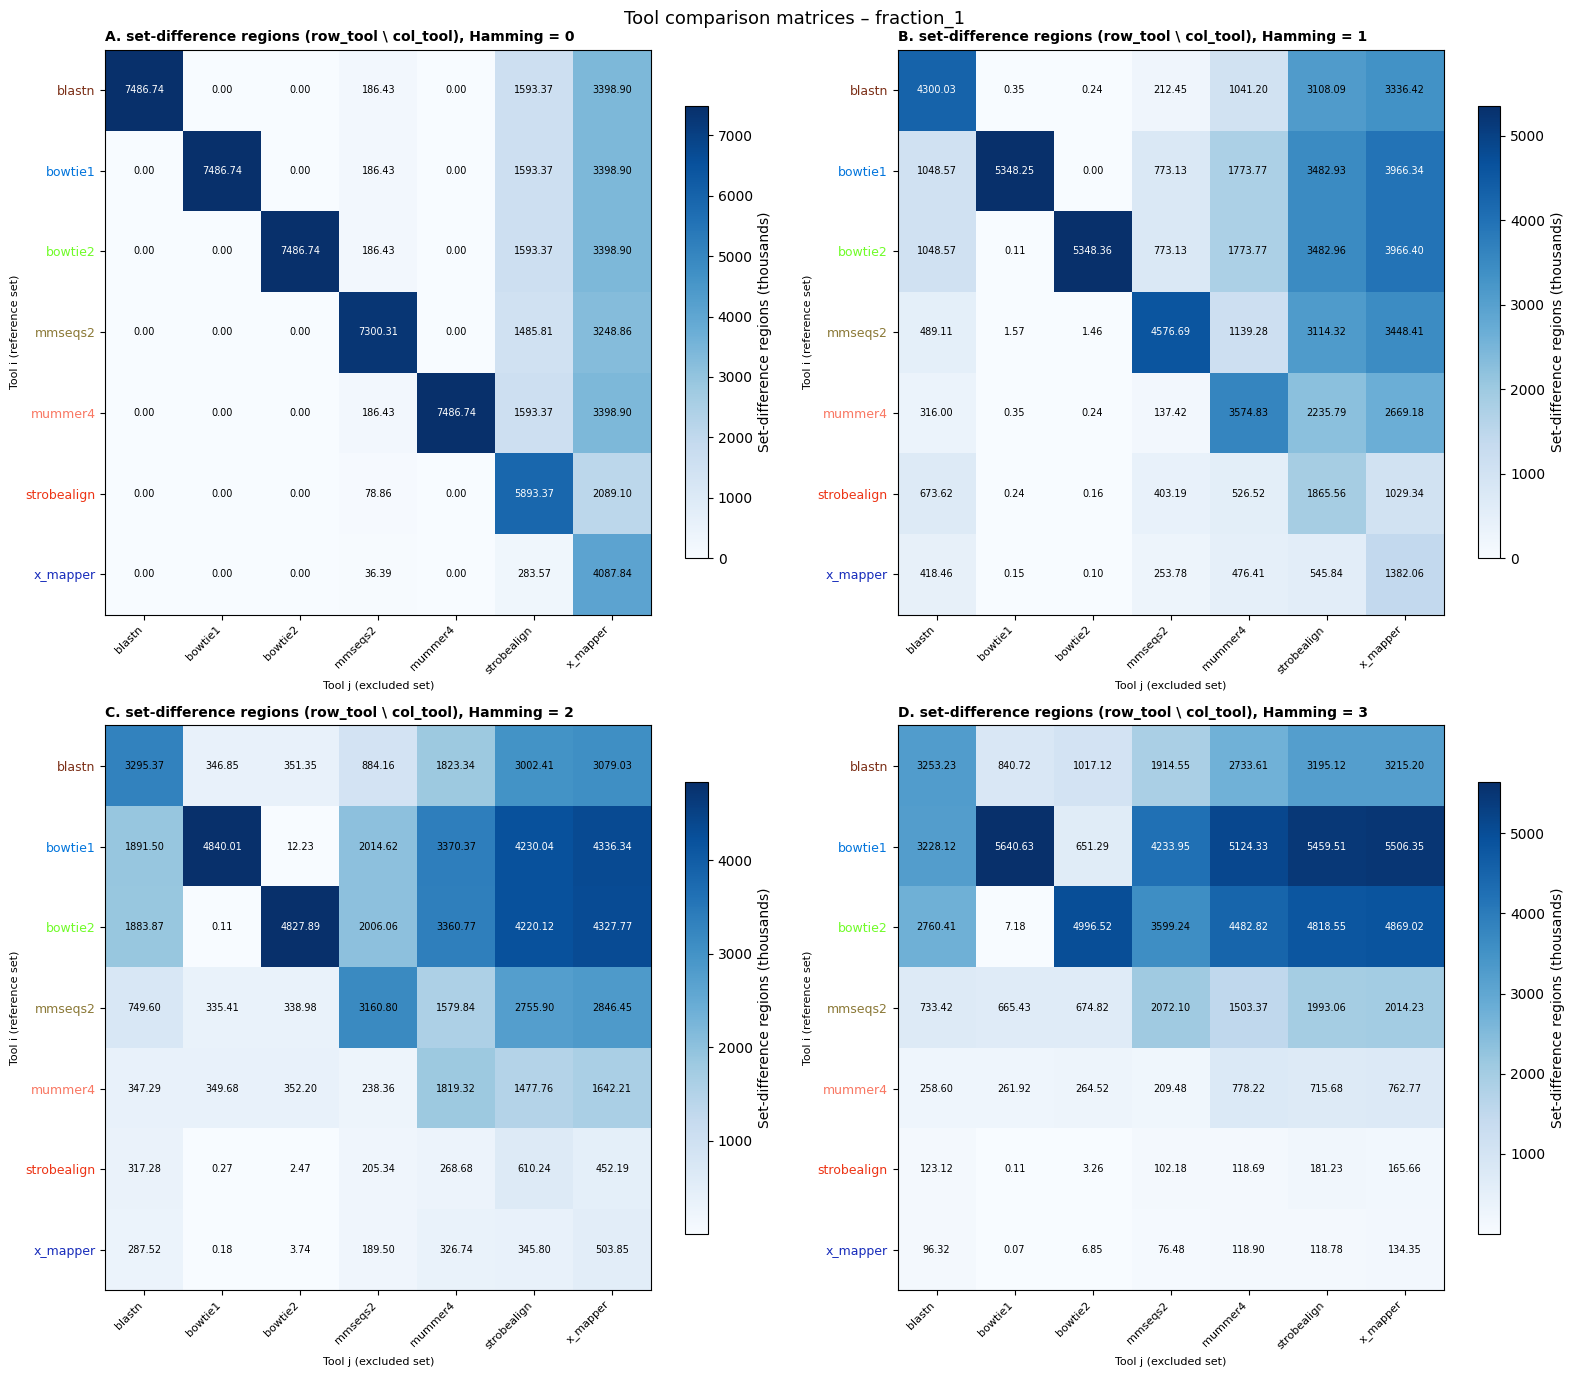

Saved imgvr4_fraction1_tool_comparison_matrix


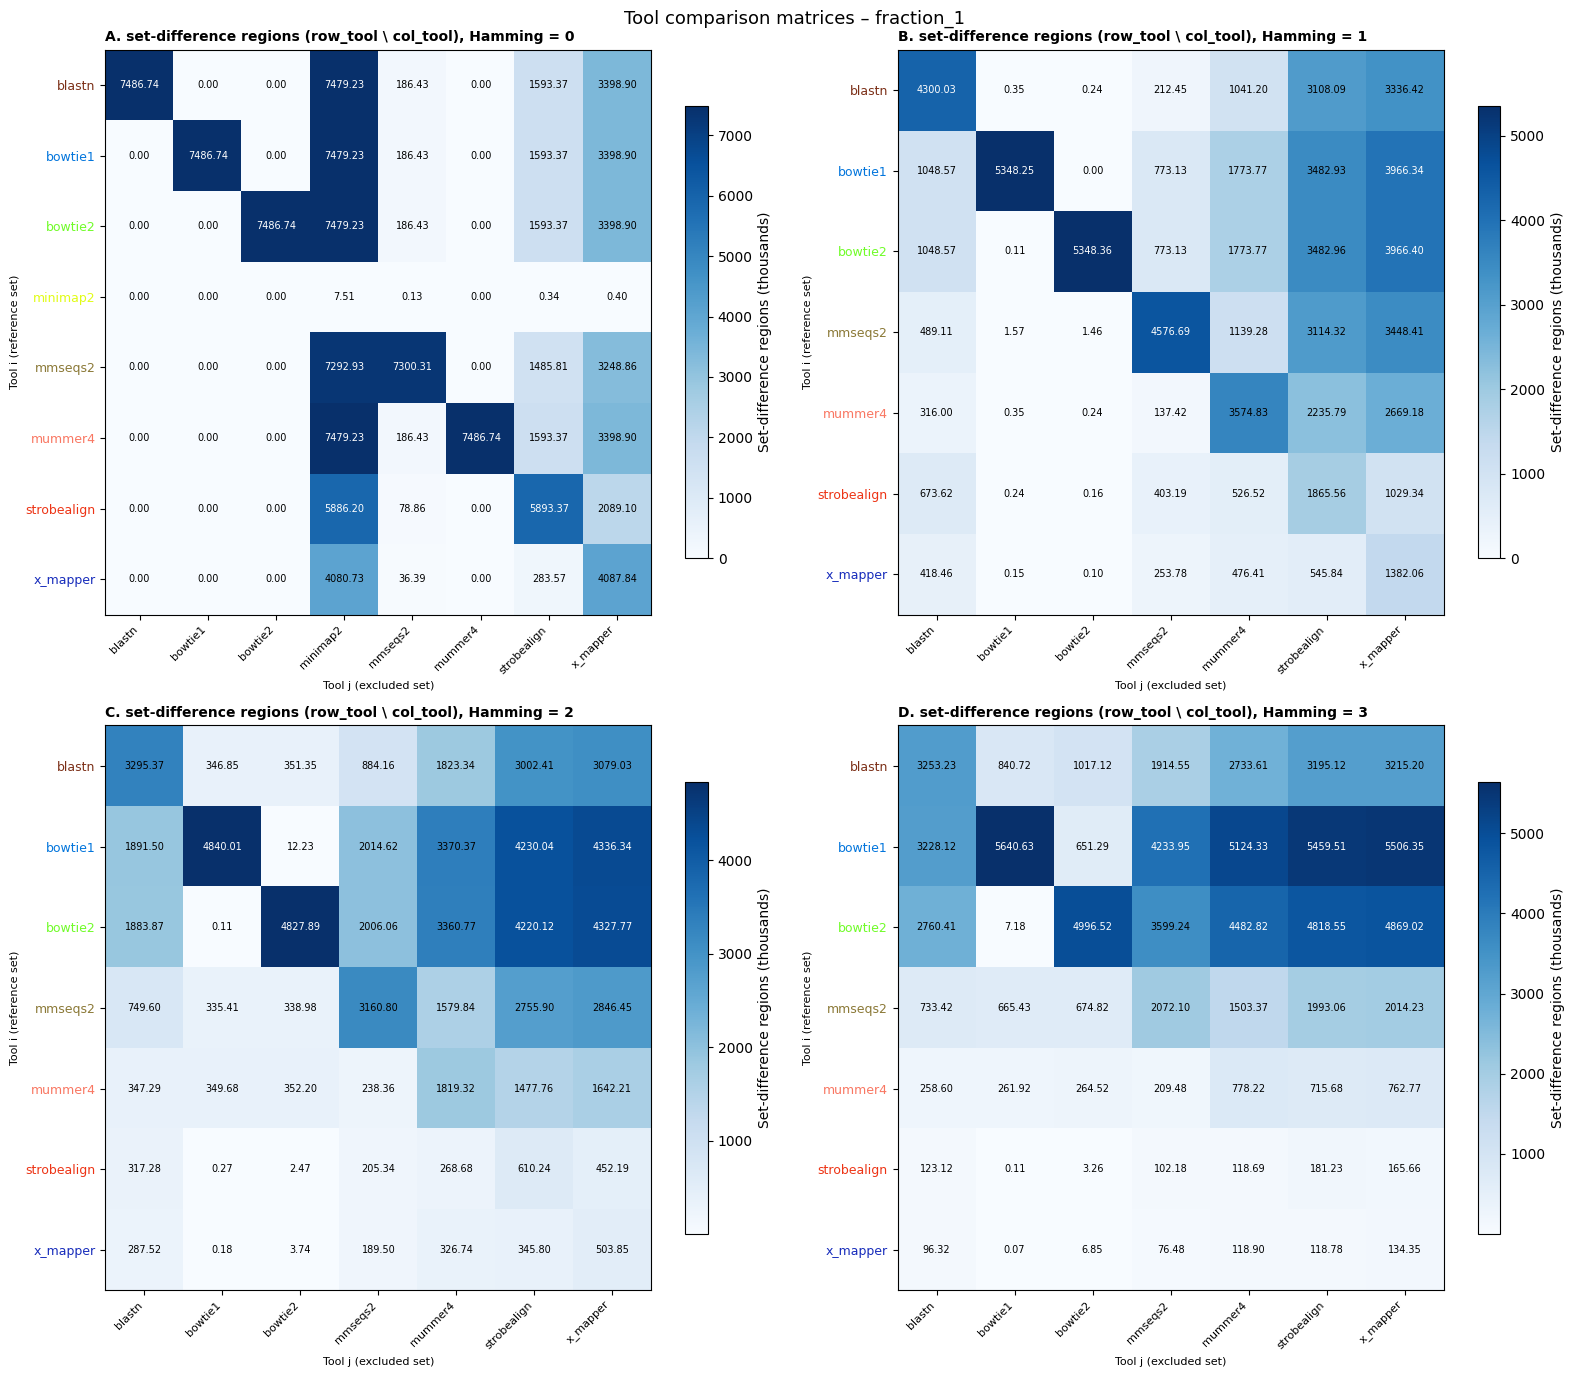

Saved imgvr4_fraction1_tool_comparison_matrix_w_minimap2


In [36]:
def create_tool_comparison_matrix(
    results_df: pl.DataFrame,
    tools_list: list[str],
    hamming_dist: int,
) -> tuple[np.ndarray, list[str]]:
    """Return (matrix, tools_present) where matrix[i,j] = regions in tool_i NOT in tool_j.

    Diagonal = total unique regions found by tool_i at this exact Hamming distance.
    Only includes tools that found at least one region.
    """
    subset = results_df.filter(pl.col('distance_hamming') == hamming_dist)
    region_key_col = (
        pl.col('spacer_id') + '|' + pl.col('contig_id') + '|' + pl.col('region_idx').cast(pl.Utf8)
    ).alias('region_key')
    keyed = subset.with_columns(region_key_col)
    tool_regions: dict[str, set] = {
        t: set(keyed.filter(pl.col('tool') == t)['region_key'].to_list())
        for t in tools_list
    }
    # Keep only tools with at least one hit
    present = [t for t in tools_list if len(tool_regions[t]) > 0]
    n = len(present)
    mat = np.zeros((n, n), dtype=int)
    for i, ti in enumerate(present):
        for j, tj in enumerate(present):
            if i == j:
                mat[i, j] = len(tool_regions[ti])
            else:
                mat[i, j] = len(tool_regions[ti] - tool_regions[tj])
    return mat, present


def plot_comparison_matrix_grid(
    results_df: pl.DataFrame,
    tools_list: list[str],
    include_minimap2: bool,
) -> plt.Figure:
    """4-panel (2×2) matplotlib grid of comparison matrices at d=0,1,2,3."""
    tlist = filter_tools(tools_list, include_minimap2=include_minimap2)
    panel_labels = ['A.', 'B.', 'C.', 'D.']
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes_flat = axes.flatten()

    for idx, d in enumerate(dist_values):
        ax = axes_flat[idx]
        mat, present = create_tool_comparison_matrix(results_df, tlist, d)
        if len(present) == 0:
            ax.axis('off')
            ax.set_title(f'{panel_labels[idx]} Hamming = {d} (no hits)', loc='left',
                         fontsize=11, fontweight='bold')
            continue

        # Display values in thousands (no k suffix)
        mat_thousands = mat / 1000.0
        im = ax.imshow(mat_thousands, aspect='auto', cmap='Blues', interpolation='nearest')
        ax.set_xticks(range(len(present)))
        ax.set_xticklabels(present, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(present)))
        ax.set_yticklabels(present, fontsize=8)

        # Color y-tick labels by tool color
        for tick, tool in zip(ax.get_yticklabels(), present):
            tick.set_color(tool_colors.get(tool, '#000000'))
            tick.set_fontsize(9)

        for ti in range(len(present)):
            for tj in range(len(present)):
                val = mat_thousands[ti, tj]
                ax.text(
                    tj, ti, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if val < mat_thousands.max() * 0.7 else 'white'
                )

        ax.set_xlabel('Tool j (excluded set)', fontsize=8)
        ax.set_ylabel('Tool i (reference set)', fontsize=8)
        ax.set_title(
            f'{panel_labels[idx]} set-difference regions (row_tool \\ col_tool), Hamming = {d}',
            loc='left', fontsize=10, fontweight='bold',
        )
        plt.colorbar(im, ax=ax, shrink=0.8, label='Set-difference regions (thousands)')

    fig.suptitle('Tool comparison matrices – fraction_1', fontsize=13)
    fig.tight_layout()
    return fig


for include_mm2 in [False, True]:
    stem = figure_stem('imgvr4_fraction1_tool_comparison_matrix', include_mm2)
    fig = plot_comparison_matrix_grid(results_hamming3, tools_in_results, include_minimap2=include_mm2)
    save_mpl_figure_bundle(fig, stem, [SUPP_FIG_DIR])
    plt.show()
    plt.close(fig)
    print(f"Saved {stem}")

# Export matrices as TSV (one file per Hamming distance, no-minimap2 version)
for d in dist_values:
    mat, present = create_tool_comparison_matrix(
        filter_tools(results_hamming3, include_minimap2=False),
        filter_tools(tools_in_results, include_minimap2=False),
        d,
    )
    mat_df = pl.DataFrame(
        {present[i]: mat[i].tolist() for i in range(len(present))},
    ).with_columns(pl.Series('tool', present)).select(['tool'] + present)
    export_table(mat_df, f'imgvr4_fraction1_comparison_matrix_hamming{d}', [SUPP_TABLE_DIR])


## Step 9: Recall vs Spacer Occurrence Frequency (Supplementary)

Two supplementary-only figures:
- A: Recall vs spacer occurrence count – fraction_1 (cumulative Hamming ≤ 3)
- B: Recall vs spacer occurrence count – HIGH_INSERTION_RATE simulation (cumulative Hamming ≤ 3)

Both figures go to `SUPP_FIG_DIR` only.
#TODO: remove one of the legends (duplicated) and move it outside of the panels.

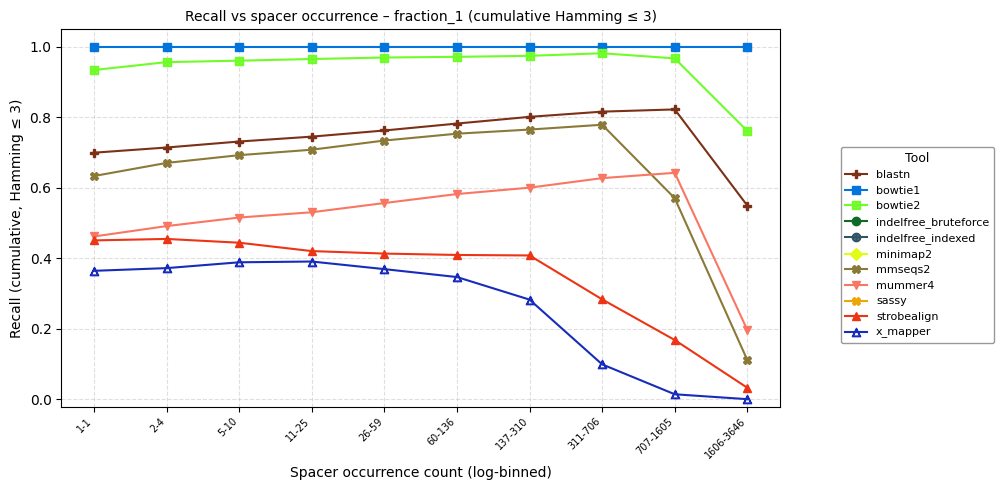

Saved imgvr4_fraction1_recall_vs_occurrence


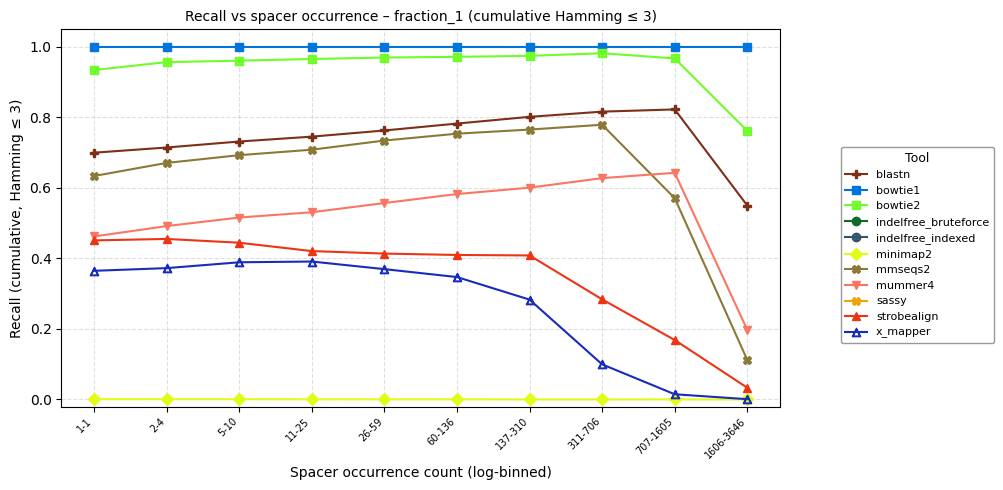

Saved imgvr4_fraction1_recall_vs_occurrence_w_minimap2


In [38]:
def create_spacer_occurrence_recall(
    results_df: pl.DataFrame,
    tools_list: list[str],
    distance_col: str = 'distance_hamming',
    max_distance: int = 3,
    n_bins: int = 10,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Compute recall by log-binned occurrence count.

    Returns (bin_edges_df, recall_df):
      - bin_edges_df: columns [bin_idx, bin_lo, bin_hi, n_spacers]
      - recall_df: columns [tool, bin_idx, n_found, n_total, recall]
    """
    # Occurrence = number of times a spacer_id appears in the ground truth (all tools, any distance)
    occ = (
        results_df.filter(pl.col(distance_col) <= max_distance)
        .select(['spacer_id', 'contig_id', 'region_idx'])
        .unique()
        .group_by('spacer_id')
        .agg(pl.len().alias('occurrence'))
    )
    # Log-space bins
    max_occ = occ['occurrence'].max()
    min_occ = occ['occurrence'].min()
    if max_occ is None or max_occ <= 1:
        log_edges = [1, 2]
    else:
        log_edges = np.unique(
            np.floor(np.logspace(0, np.log10(max_occ + 1), n_bins + 1)).astype(int)
        ).tolist()
    bins_records = [
        {'bin_idx': i, 'bin_lo': int(log_edges[i]), 'bin_hi': int(log_edges[i + 1]) - 1}
        for i in range(len(log_edges) - 1)
    ]
    bins_df = pl.DataFrame(bins_records)

    occ_with_bin = occ.with_columns(
        pl.lit(0).alias('bin_idx')
    )
    # Assign bins
    assigned_records = []
    for row in occ.iter_rows(named=True):
        bid = 0
        for b in bins_records:
            if b['bin_lo'] <= row['occurrence'] <= b['bin_hi']:
                bid = b['bin_idx']
                break
        assigned_records.append({'spacer_id': row['spacer_id'], 'bin_idx': bid})
    spacer_bin = pl.DataFrame(assigned_records)

    bins_n = (
        spacer_bin.group_by('bin_idx')
        .agg(pl.len().alias('n_spacers'))
        .join(bins_df, on='bin_idx')
        .sort('bin_idx')
    )

    recall_records = []
    for b in bins_records:
        spacers_in_bin = set(
            spacer_bin.filter(pl.col('bin_idx') == b['bin_idx'])['spacer_id'].to_list()
        )
        total_regions = (
            results_df.filter(
                pl.col('spacer_id').is_in(spacers_in_bin) &
                (pl.col(distance_col) <= max_distance)
            )
            .select(['spacer_id', 'contig_id', 'region_idx']).unique().height
        )
        for tool in tools_list:
            found = (
                results_df.filter(
                    (pl.col('tool') == tool) &
                    pl.col('spacer_id').is_in(spacers_in_bin) &
                    (pl.col(distance_col) <= max_distance)
                )
                .select(['spacer_id', 'contig_id', 'region_idx']).unique().height
            )
            recall_records.append({
                'tool': tool,
                'bin_idx': b['bin_idx'],
                'n_found': found,
                'n_total': total_regions,
                'recall': found / total_regions if total_regions > 0 else float('nan'),
            })
    return bins_n, pl.DataFrame(recall_records)


def plot_occurrence_recall(
    bins_n: pl.DataFrame,
    recall_df: pl.DataFrame,
    tools_list: list[str],
    include_minimap2: bool,
    title: str,
) -> plt.Figure:
    """Line plot of recall vs log-binned spacer occurrence."""
    tlist = filter_tools(tools_list, include_minimap2=include_minimap2)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(title, fontsize=10)
    for tool in tlist:
        td = recall_df.filter(pl.col('tool') == tool).sort('bin_idx')
        color = tool_colors.get(tool, '#888888')
        marker = tool_markers_mpl.get(tool, 'o')
        ax.plot(
            td['bin_idx'].to_list(),
            td['recall'].to_list(),
            color=color, marker=marker, label=tool, linewidth=1.5, markersize=6,
        )
    tick_positions = bins_n['bin_idx'].to_list()
    tick_labels = [
        f"{r['bin_lo']}-{r['bin_hi']}"
        for r in bins_n.iter_rows(named=True)
    ]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
    ax.set_xlabel('Spacer occurrence count (log-binned)')
    ax.set_ylabel('Recall (cumulative, Hamming ≤ 3)')
    ax.set_ylim(-0.02, 1.05)
    # ax.legend(fontsize=8, loc='lower right', title='Tool')



    ax.grid(True, linestyle='--', alpha=0.4)
    fig.legend(
        handles, labels,
        loc='center left',
        bbox_to_anchor=(1.05, 0.5),
        frameon=True,
        edgecolor='gray',
        title='Tool',
        fontsize=8,
        title_fontsize=9,
    )
    fig.tight_layout()
    return fig


# --- fraction_1 ---
bins_n_f1, occ_recall_f1 = create_spacer_occurrence_recall(
    results_hamming3, tools_in_results, 'distance_hamming', MAX_HAMMING_DISTANCE
)
for include_mm2 in [False, True]:
    stem = figure_stem('imgvr4_fraction1_recall_vs_occurrence', include_mm2)
    tlist = filter_tools(tools_in_results, include_minimap2=include_mm2)
    fig = plot_occurrence_recall(
        bins_n_f1, occ_recall_f1, tlist, include_mm2,
        title='Recall vs spacer occurrence – fraction_1 (cumulative Hamming ≤ 3)',
    )
    save_mpl_figure_bundle(fig, stem, [SUPP_FIG_DIR])
    plt.show()
    plt.close(fig)
    print(f"Saved {stem}")

export_table(occ_recall_f1, 'imgvr4_fraction1_recall_vs_occurrence', [SUPP_TABLE_DIR])


HIGH_INS rows: 3,440,452, tools: ['all_tools_combined', 'blastn', 'bowtie1', 'bowtie2', 'indelfree_bruteforce', 'indelfree_indexed', 'mmseqs2', 'mummer4', 'sassy', 'strobealign', 'x_mapper']


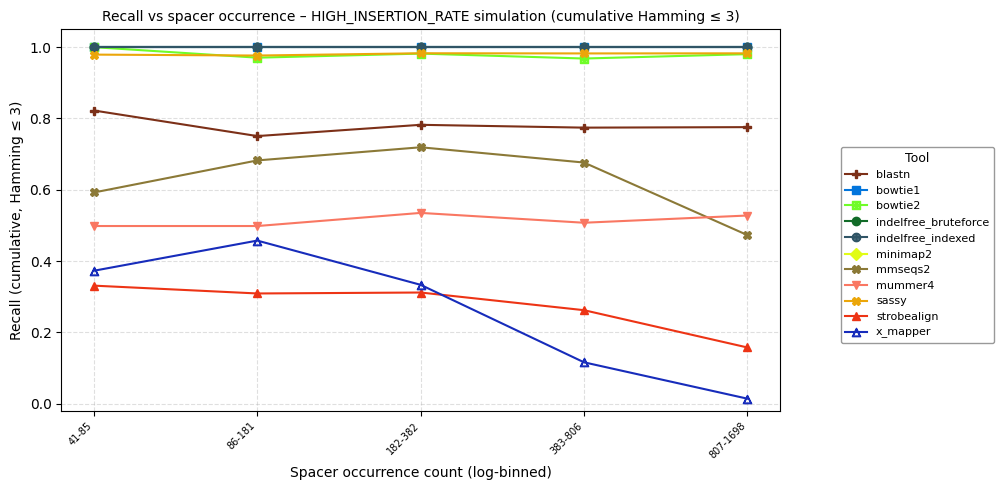

Saved imgvr4_high_ins_recall_vs_occurrence


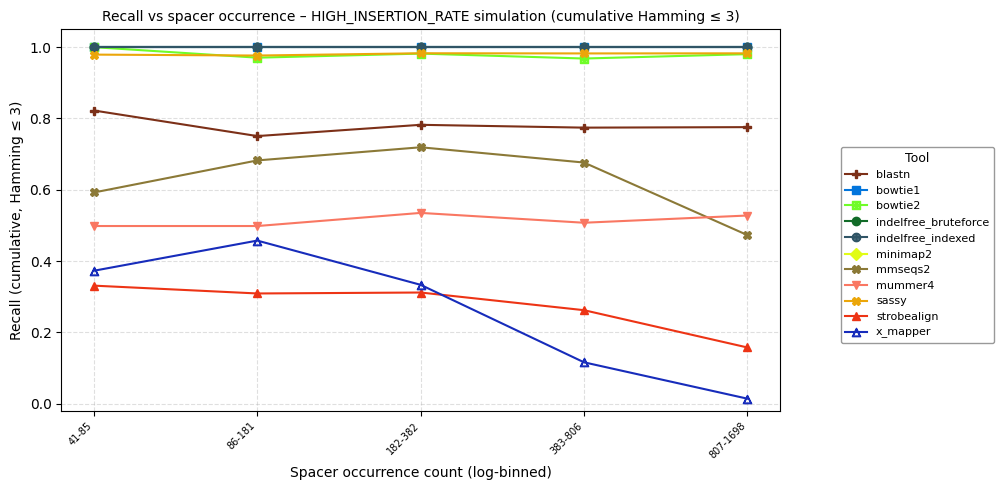

Saved imgvr4_high_ins_recall_vs_occurrence_w_minimap2


In [40]:
# --- HIGH_INSERTION_RATE simulation ---
high_ins_df = (
    pl.read_parquet(HIGH_INS_SIM_DIR / 'multi_metric_distances.parquet')
    .explode('tools')
    .rename({'tools': 'tool'})
    .filter(pl.col('distance_hamming') <= MAX_HAMMING_DISTANCE)
)
tools_high_ins = sorted(high_ins_df['tool'].unique().to_list())
print(f"HIGH_INS rows: {high_ins_df.height:,}, tools: {tools_high_ins}")

bins_n_hi, occ_recall_hi = create_spacer_occurrence_recall(
    high_ins_df, tools_high_ins, 'distance_hamming', MAX_HAMMING_DISTANCE
)
for include_mm2 in [False, True]:
    stem = figure_stem('imgvr4_high_ins_recall_vs_occurrence', include_mm2)
    tlist = filter_tools(tools_high_ins, include_minimap2=include_mm2)
    fig = plot_occurrence_recall(
        bins_n_hi, occ_recall_hi, tlist, include_mm2,
        title='Recall vs spacer occurrence – HIGH_INSERTION_RATE simulation (cumulative Hamming ≤ 3)',
    )
    save_mpl_figure_bundle(fig, stem, [SUPP_FIG_DIR])
    plt.show()
    plt.close(fig)
    print(f"Saved {stem}")

export_table(occ_recall_hi, 'imgvr4_high_ins_recall_vs_occurrence', [SUPP_TABLE_DIR])


## Step 10: Spacer Match Distribution Analysis (Supplementary)

Three-panel figure:
- A: Spacer length distribution
- B: Hamming distance distribution of all matches (fraction_1, d ≤ 3)
- C: Occurrence count distribution (log scale) across all fractions (fraction_1 reference)

Saved to `SUPP_FIG_DIR` only.


From previous version of the notebook (needs adjustmends)

In [46]:
import altair as alt
def plot_spacer_distributions(results_df, spacer_counts_with_tools, output_prefix='results/real_data/subsamples_analysis/plots_fraction_1'):
    """
    Create a three-panel figure showing spacer length, Hamming distance, and occurrence distributions.
    
    Args:
        results_df: DataFrame with validated alignments
        spacer_counts_with_tools: DataFrame with spacer occurrence counts
        output_prefix: Directory prefix for saving plots
    """
    # Get unique alignments for distribution analysis
    unique_alignments = results_df.select([
        'spacer_id', 'contig_id', 'start', 'end', 'strand', 'distance_hamming'
    ]).unique()
    
    # Calculate spacer lengths from alignment coordinates
    unique_alignments = unique_alignments.with_columns(
        (pl.col('end') - pl.col('start')).alias('spacer_length')
    )

    # Get distributions
    occurrence_df = spacer_counts_with_tools['n_occurrences'].value_counts()
    hamming_df = unique_alignments['distance_hamming'].value_counts()
    length_df = unique_alignments['spacer_length'].value_counts()

    # Chart 1: Spacer length distribution
    chart1 = alt.Chart(length_df).mark_bar().encode(
        x=alt.X('spacer_length:Q', 
                title='Spacer Length (bp)', 
                axis=alt.Axis(grid=True)),
        y=alt.Y("count:Q", 
                axis=alt.Axis(title="Number of Alignments", grid=True, gridDash=[2,2]))
    ).properties(
        title='A. Spacer Length Distribution',
        width=250,
        height=200
    )

    # Chart 2: Occurrence distribution (log scale)
    chart2 = alt.Chart(occurrence_df).mark_bar(opacity=0.7).encode(
        x=alt.X('n_occurrences:Q',
                scale=alt.Scale(type='log'),
                title='Number of Occurrences (log scale)'),
        y=alt.Y('count:Q', title='Number of Spacers')
    ).properties(
        title='B. Occurrence Distribution',
        width=250,
        height=200
    )

    # Chart 3: Hamming distance distribution
    chart3 = alt.Chart(hamming_df).mark_bar(width=40).encode(
        x=alt.X('distance_hamming:Q', 
                title='Hamming Distance', 
                axis=alt.Axis(grid=True)),
        y=alt.Y("count:Q", 
                axis=alt.Axis(title="Number of Alignments", grid=True, gridDash=[2,2]))
    ).properties(
        title='C. Hamming Distance Distribution',
        width=250,
        height=200
    )
    
    # Combine charts
    combined_chart = (chart1 | chart2 | chart3).configure_axis(
        labelFontSize=11,
        titleFontSize=12
    ).configure_title(
        anchor='start',
        fontSize=13
    )
    
    return combined_chart

def create_spacer_counts_with_tools(results_df, tools_list, hamming_distance=3, exact_or_max="exact"):
    """
    Create spacer occurrence counts with tool detection fractions.
    Uses region_idx to properly handle coordinate tolerance.
    """
    if exact_or_max == "max":
        spacer_counts = results_df.filter(pl.col('distance_hamming') <= hamming_distance)
    else:
        spacer_counts = results_df.filter(pl.col('distance_hamming') == hamming_distance)
    
    spacer_counts = spacer_counts.select(["spacer_id", "contig_id", "region_idx"])\
        .unique()\
        .group_by('spacer_id')\
        .agg(pl.count('region_idx').alias('n_occurrences'))

    # Calculate matches per tool and spacer using region_idx
    if exact_or_max == "max":
        tool_matches = results_df.filter(pl.col('distance_hamming') <= hamming_distance)
    else:
        tool_matches = results_df.filter(pl.col('distance_hamming') == hamming_distance)
    
    tool_matches = tool_matches.select(['spacer_id', 'tool', 'contig_id', 'region_idx'])\
        .unique()\
        .group_by(['spacer_id', 'tool'])\
        .agg(pl.count('region_idx').alias('tool_matches'))

    # Cross join and calculate fractions
    all_combinations = spacer_counts.select('spacer_id', 'n_occurrences')\
        .join(pl.DataFrame({'tool': tools_list}), how='cross')

    complete_fractions = all_combinations\
        .join(tool_matches, on=['spacer_id', 'tool'], how='left')\
        .with_columns([
            pl.col('tool_matches').fill_null(0),
            (pl.col('tool_matches') / pl.col('n_occurrences')).alias('fraction')
        ])

    # Pivot to tools as columns
    spacer_counts_with_tools = complete_fractions\
        .pivot(index=['spacer_id', 'n_occurrences'], on='tool', values='fraction')\
        .fill_null(0)
    
    return spacer_counts_with_tools

spacer_counts_with_tools = create_spacer_counts_with_tools(results_hamming3, tools_in_results, hamming_distance=3, exact_or_max="exact")
# Create distribution plots
combined_chart = plot_spacer_distributions(
    results_df=results_hamming3,
    spacer_counts_with_tools=spacer_counts_with_tools
)
combined_chart

# Summary statistics for fraction_1
unique_alignments = results_hamming3.select([
    'spacer_id', 'contig_id', 'start', 'end', 'distance_hamming'
]).unique()

unique_alignments = unique_alignments.with_columns(
    (pl.col('end') - pl.col('start')).alias('spacer_length')
)

print("Summary Statistics for Fraction_1 (Hamming ≤ 3):")
print(f"Spacer Lengths: mean={unique_alignments['spacer_length'].mean():.2f} bp, "
      f"median={unique_alignments['spacer_length'].median():.2f} bp, "
      f"std={unique_alignments['spacer_length'].std():.2f} bp")

print(f"Hamming Distances: mean={unique_alignments['distance_hamming'].mean():.2f}, "
      f"median={unique_alignments['distance_hamming'].median():.2f}, "
      f"std={unique_alignments['distance_hamming'].std():.2f}")

print(f"Occurrences per Spacer: mean={spacer_counts_with_tools['n_occurrences'].mean():.2f}, "
      f"median={spacer_counts_with_tools['n_occurrences'].median():.2f}, "
      f"std={spacer_counts_with_tools['n_occurrences'].std():.2f}")

print(f"\nDataset: {unique_alignments.height:,} unique alignments, "
      f"{unique_alignments['spacer_id'].n_unique():,} spacers, "
      f"{unique_alignments['contig_id'].n_unique():,} contigs, "
      f"{len(tools_in_results)} tools")

Summary Statistics for Fraction_1 (Hamming ≤ 3):
Spacer Lengths: mean=32.36 bp, median=33.00 bp, std=2.84 bp
Hamming Distances: mean=1.54, median=2.00, std=1.17
Occurrences per Spacer: mean=14.10, median=3.00, std=42.69

Dataset: 27,883,600 unique alignments, 750,246 spacers, 323,183 contigs, 8 tools


In [47]:
combined_chart

alt.HConcatChart(...)

## Summary: Output Paths

All figures and tables have been saved to the following directories:

**Main text figures** (`draft/main/figures/`):
- `imgvr4_cross_fraction_consistency.svg/.png`
- `imgvr4_fraction1_hamming_recall.svg/.png`
- `imgvr4_heatmap_hamming_vs_edit.svg/.png`

**Supplementary figures** (`draft/supp/figures/`):
- `imgvr4_cross_fraction_consistency_w_minimap2.svg/.png`
- `imgvr4_fraction1_upset_hamming{0,1,2,3}.svg/.png`
- `imgvr4_fraction1_hamming_recall_w_minimap2.svg/.png`
- `imgvr4_sassy_fractions_edit_recall.svg/.png`  (+ `_w_minimap2`)
- `imgvr4_heatmap_hamming_vs_edit_w_minimap2.svg/.png`
- `imgvr4_fraction1_tool_comparison_matrix.svg/.png`  (+ `_w_minimap2`)
- `imgvr4_fraction1_recall_vs_occurrence.svg/.png`  (+ `_w_minimap2`)
- `imgvr4_high_ins_recall_vs_occurrence.svg/.png`  (+ `_w_minimap2`)
- `imgvr4_distribution_analysis.svg/.png`

**Supplementary tables** (`draft/supp/tables/`):
- `imgvr4_sequence_stats.tsv`
- `imgvr4_fraction1_tool_summary_hamming_le3.tsv`
- `imgvr4_fraction1_hamming_recall_{exact,cumulative}.tsv`
- `imgvr4_fraction1_hamming_exact_recall_table.tsv`
- `imgvr4_sassy_fractions_edit_recall_{exact,cumulative}.tsv`
- `imgvr4_sassy_edit_exact_recall_mean_table.tsv`
- `imgvr4_fraction1_comparison_matrix_hamming{0,1,2,3}.tsv`
- `imgvr4_fraction1_recall_vs_occurrence.tsv`
- `imgvr4_high_ins_recall_vs_occurrence.tsv`
- `imgvr4_fraction1_hamming_distribution.tsv`
- `imgvr4_fraction1_occurrence_distribution.tsv`
- `imgvr4_fraction_recall_pivot.tsv`

**Main text tables** (`draft/main/tables/`):
- `imgvr4_fraction_recall_pivot.tsv` (cross-fraction recall summary)

Side-by-side panels combining real-data and simulated results are handled in
`notebooks/figure_cleanups.ipynb`.


In [ ]:
# %%bash
# # Archive analysis results
# tar -czf results/real_data/subsamples_analysis.tar.gz results/real_data/subsamples_analysis/
# realpath results/real_data/subsamples_analysis.tar.gz
# # # echo "Archive created: results/real_data/subsamples_analysis.tar.gz"
# %%bash
# du -sh results/real_data/subsamples_analysis.tar.gz